# Ranking de post-procesamiento — axis_sym / plane_sym

Lee `all_experiments_comparison.csv` / los CSV por tipo de simetria que genera
`Mapping/compare_results.py` (una fila por combinacion `experiment x method x n_views`) y
construye, en orden:

1. **Carga y enriquecimiento**: parsea cada `experiment` id (prompt base, flow, clustering,
   patch-size), le agrega la descripcion legible del prompt, su `point_mode`
   (`independent`/`midpoint`, desde `MolmoPointing/Experiments.md`), su familia (`v0` original
   vs `v1` mejorado) y la tasa de aceptacion (`n_objects / n_total`).
2. **Validacion de integridad**: duplicados exactos, contaminacion cruzada entre tipos de
   simetria, cobertura vs. el registro completo de 24 prompts + Flow B/C + 7 variantes de
   post-procesamiento por experimento, y filas faltantes explicadas automaticamente por
   `point_mode` (n_views=1 es imposible en prompts `midpoint`). Termina en un veredicto.
3. **Inventario**: que prompts/experimentos/variantes quedaron documentados.
4. **Metricas por tipo de simetria**: un diccionario unico (`AXIS_METRICS` / `PLANE_METRICS`)
   que alimenta todas las tablas de abajo — agregar o quitar una metrica es editar una linea.
5. **Resumen ejecutivo**: el mejor resultado global obtenido por metrica, listo para pegar en la
   seccion de Resultados de la tesis.
6. **Ranking por experimento**: para cada `experiment` (prompt+flow+clustering+patch), su mejor
   fila (method+n_views) por metrica.
7. **Ranking por tipo de prompt**: igual que (6) pero agregando sobre TODAS las variantes de un
   mismo prompt base — responde "que diseño de prompt funciona mejor", independiente del
   post-procesamiento aplicado.
8. **Ablation de post-procesamiento**: efecto aislado de clustering, patch-size, metodo de
   ajuste y point-mode (mas flow, confundido con la eleccion de prompt) — tablas + graficos de
   barra (paleta validada del skill de dataviz).
9. **Tendencia de n_views**: ¿mas vistas mejora la precision? Linea v0 vs v1.
10. **Ranking conjunto**: combina dos metricas por suma de rangos (ajustable).
11. **Guardado**: exporta todas las tablas (incluido el reporte de validacion) a
    `<EXPERIMENTS_DIR>/rankings/`.

Al final se deja, como anexo, el reporte de errores en los logs de ejecucion.

In [1]:
import re
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

## 0. Configuracion

Ajusta `EXPERIMENTS_DIR` si corres esto otro dia (o descomenta la linea de "mas reciente" para
no tener que tocarlo cada vez).

In [2]:
import re as _re
from datetime import date as _date

def _find_latest_experiments_dir() -> Path:
    """Busca carpetas experiments_DD_MM_YYYY tanto en la raiz del repo como bajo
    results/, y devuelve la de fecha mas reciente (por el nombre, no por mtime)."""
    candidates = list(Path(".").glob("experiments_*")) + list(Path("results").glob("experiments_*"))
    dated = []
    for p in candidates:
        m = _re.match(r"experiments_(\d{2})_(\d{2})_(\d{4})$", p.name)
        if m and p.is_dir():
            d, mo, y = map(int, m.groups())
            dated.append((_date(y, mo, d), p))
    if not dated:
        raise FileNotFoundError("No se encontro ninguna carpeta experiments_DD_MM_YYYY en '.' ni en 'results/'")
    return max(dated, key=lambda t: t[0])[1]

# Auto-detecta la carpeta experiments_DD_MM_YYYY mas reciente (busca en la raiz del repo
# y en results/) para no tener que editar esto cada vez que sincronizas resultados nuevos.
# Fija la linea de abajo a mano si necesitas reproducibilidad exacta sobre un corte pasado.
EXPERIMENTS_DIR = _find_latest_experiments_dir()
# EXPERIMENTS_DIR = Path("experiments_17_08_2026")

AXIS_CSV = EXPERIMENTS_DIR / "axis_sym_comparison.csv"
PLANE_CSV = EXPERIMENTS_DIR / "plane_sym_comparison.csv"
ALL_CSV = EXPERIMENTS_DIR / "all_experiments_comparison.csv"

TOP_N = 15  # cuantas filas mostrar por tabla

# n_views=1 solo aporta ~2 puntos por objeto al ajuste (ver columna n_points_mean) -> metricas
# ruidosas e infladas artificialmente en muestras chicas. Sube MIN_N_VIEWS (p.ej. 6) para exigir
# al menos esa cantidad de vistas, o deja en 1 para no filtrar nada.
MIN_N_VIEWS = 1
MIN_N_OBJECTS = 0  # minimo de objetos evaluados para que una fila cuente

print(f"EXPERIMENTS_DIR : {EXPERIMENTS_DIR}")
print(f"Axis CSV : {AXIS_CSV}  (existe={AXIS_CSV.exists()})")
print(f"Plane CSV: {PLANE_CSV}  (existe={PLANE_CSV.exists()})")
print(f"All CSV  : {ALL_CSV}  (existe={ALL_CSV.exists()})")

EXPERIMENTS_DIR : experiments_17_08_2026
Axis CSV : experiments_17_08_2026\axis_sym_comparison.csv  (existe=True)
Plane CSV: experiments_17_08_2026\plane_sym_comparison.csv  (existe=True)
All CSV  : experiments_17_08_2026\all_experiments_comparison.csv  (existe=True)


## 1. Cargar, parsear y enriquecer

`experiment` viene como `<prompt_base>[_flow{B,C}][_cluster | _hdbscan_ms{N}][_p{3,5}]`, en
cualquier orden de sufijos (p.ej. `axis_v05_1_flowB_p3_cluster` o `axis_v00_p3_hdbscan_ms2`).
`parse_experiment_id` los va despojando desde el final hasta quedarse con el prompt base.

Ademas se agrega:
- `prompt_description`: texto de `MolmoPointing/prompts_registry.py` (`DESCRIPTIONS`), que
  documenta que estrategia de puntos usa cada prompt.
- `prompt_family`: `"v1 (mejorado)"` si el prompt base termina en `_1` (p.ej. `axis_v05_1`),
  `"v0 (original)"` en caso contrario.
- `acceptance_rate`: `n_objects / n_total` — cuantos objetos del dataset lograron una prediccion
  valida. Un AUC alto con `acceptance_rate` bajo es un resultado poco representativo.

In [3]:
def parse_experiment_id(exp_id: str) -> dict:
    remaining = exp_id
    clustering = "none"
    patch_size = 1
    flow = "A"
    changed = True
    while changed:
        changed = False
        if m := re.search(r"_hdbscan_ms(\d+)$", remaining):
            clustering = f"hdbscan_ms{m.group(1)}"
            remaining = remaining[: m.start()]
            changed = True
            continue
        if m := re.search(r"_cluster$", remaining):
            clustering = "greedy"
            remaining = remaining[: m.start()]
            changed = True
            continue
        if m := re.search(r"_p([0-9]+)$", remaining):
            patch_size = int(m.group(1))
            remaining = remaining[: m.start()]
            changed = True
            continue
        if m := re.search(r"_flow([ABC])$", remaining):
            flow = m.group(1)
            remaining = remaining[: m.start()]
            changed = True
            continue
    return {"base_prompt": remaining, "flow": flow, "clustering": clustering, "patch_size": patch_size}

In [4]:
# Copiado de MolmoPointing/prompts_registry.py::DESCRIPTIONS — que estrategia de puntos
# testea cada prompt base. Si agregas un prompt nuevo, agrega su descripcion aqui tambien.
PROMPT_DESCRIPTIONS: dict[str, str] = {
    # Axis variants
    "axis_v00": "Axis projection — two far-apart points directly on the projected axis",
    "axis_v01": "Bilateral pair — left/right mirror points equidistant from the axis",
    "axis_v02": "Widest silhouette extrema — leftmost and rightmost at the widest cross-section",
    "axis_v03": "Structural feature pairs — visually symmetric elements (handles, holes, ribs)",
    "axis_v04": "Polar extremes — topmost and bottommost points where the axis exits the surface",
    "axis_v05": "Axis centerline — one point upper half + one point lower half on the centerline",
    # Plane variants
    "plane_v00": "Plane trace — top and bottom points on the plane's surface intersection",
    "plane_v01": "Bilateral pair — left/right mirror points equidistant from the symmetry plane",
    "plane_v02": "Plane seam — two points directly on the plane's surface trace (top and bottom)",
    "plane_v03": "Structural feature pairs — corresponding symmetric elements across the plane",
    "plane_v04": "Silhouette midpoints — horizontal center of left-right extent at top and bottom",
    "plane_v05": "Plane trace extremes — two most distant points along the visible plane trace",
    # Axis v1 variants (improved with centerline definition + upper/lower split + fallbacks)
    "axis_v00_1": "Axis projection v1 — upper/lower split, centerline definition, no silhouette edges",
    "axis_v01_1": "Bilateral pair v1 — height diversity across views, midpoint on centerline verified",
    "axis_v02_1": "Widest cross-section v1 — returns centerline midpoints at widest + top/bottom heights",
    "axis_v03_1": "Structural pairs v1 — midpoint verification + widest cross-section fallback",
    "axis_v04_1": "Polar extremes v1 — horizontal center verification + flat-surface fallback",
    "axis_v05_1": "Axis centerline v1 — explicit step-0 global axis identification, consistency check",
    # Plane v1 variants (improved with top/bottom split + midpoint verification + height diversity)
    "plane_v00_1": "Plane trace v1 — explicit top/bottom split + horizontal center guidance",
    "plane_v01_1": "Bilateral pair v1 — height diversity across views, midpoint on trace verified",
    "plane_v02_1": "Plane seam v1 — global plane step-0, consistency across views, top/bottom enforced",
    "plane_v03_1": "Structural pairs v1 — midpoint verification + widest cross-section fallback",
    "plane_v04_1": "Silhouette midpoints v1 — step-0 global plane ID + cross-view consistency check",
    "plane_v05_1": "Plane trace v1 — topmost/bottommost on trace, vertical separation explicit",
}

# Copiado de MolmoPointing/Experiments.md (tabla de prompts registrados). "midpoint" no puede
# producir resultados con n_views=1 (un solo par de puntos -> un solo midpoint -> el SVD
# necesita >=2 -> estimate_symmetry.py descarta el objeto), asi que esos prompts SIEMPRE van
# a faltarles la fila n_views=1 sin importar cuantas veces se re-corra el post-procesamiento.
POINT_MODE: dict[str, str] = {
    "axis_v00": "independent", "axis_v01": "midpoint",    "axis_v02": "midpoint",
    "axis_v03": "midpoint",    "axis_v04": "independent", "axis_v05": "independent",
    "axis_v00_1": "independent", "axis_v01_1": "midpoint",    "axis_v02_1": "independent",
    "axis_v03_1": "midpoint",    "axis_v04_1": "independent", "axis_v05_1": "independent",
    "plane_v00": "independent", "plane_v01": "midpoint",    "plane_v02": "independent",
    "plane_v03": "midpoint",    "plane_v04": "independent", "plane_v05": "independent",
    "plane_v00_1": "independent", "plane_v01_1": "midpoint",    "plane_v02_1": "independent",
    "plane_v03_1": "midpoint",    "plane_v04_1": "independent", "plane_v05_1": "independent",
}


def enrich(df: pd.DataFrame) -> pd.DataFrame:
    parsed = df["experiment"].apply(parse_experiment_id).apply(pd.Series)
    df = pd.concat([df, parsed], axis=1)
    df["prompt_description"] = df["base_prompt"].map(PROMPT_DESCRIPTIONS).fillna("(sin descripcion)")
    df["prompt_family"] = df["base_prompt"].apply(lambda p: "v1 (mejorado)" if p.endswith("_1") else "v0 (original)")
    # flowC siempre usa point-mode "all" (no independent/midpoint); ver estimate_symmetry.py
    df["point_mode"] = df.apply(
        lambda r: "all (flowC)" if r["flow"] == "C" else POINT_MODE.get(r["base_prompt"], "?"),
        axis=1,
    )
    df["acceptance_rate"] = df["n_objects"] / df["n_total"]
    return df


def load_and_parse(csv_path: Path) -> pd.DataFrame:
    return enrich(pd.read_csv(csv_path))


def apply_min_filters(df: pd.DataFrame) -> pd.DataFrame:
    return df[(df["n_views"] >= MIN_N_VIEWS) & (df["n_objects"] >= MIN_N_OBJECTS)].reset_index(drop=True)


axis_df_all = load_and_parse(AXIS_CSV)
plane_df_all = load_and_parse(PLANE_CSV)

axis_df = apply_min_filters(axis_df_all)
plane_df = apply_min_filters(plane_df_all)

print(f"axis_sym : {axis_df_all.shape[0]} filas -> {axis_df.shape[0]} tras filtro, {axis_df['experiment'].nunique()} experimentos distintos")
print(f"plane_sym: {plane_df_all.shape[0]} filas -> {plane_df.shape[0]} tras filtro, {plane_df['experiment'].nunique()} experimentos distintos")

axis_sym : 1684 filas -> 1684 tras filtro, 114 experimentos distintos
plane_sym: 1584 filas -> 1584 tras filtro, 106 experimentos distintos


## 1b. Validacion de integridad — duplicados, cobertura vs. registro completo

Antes de confiar en cualquier ranking de abajo, confirma que el CSV no tiene sorpresas:

- **Filas duplicadas exactas** (mismo `experiment` + `method` + `n_views` repetido).
- **Contaminacion cruzada**: un mismo `experiment` id apareciendo en ambos `axis_sym` y `plane_sym`.
- **Cobertura vs. el registro completo**: 12 prompts axiales + 12 planares (`MolmoPointing/Experiments.md`),
  Flow B/C solo sobre el prompt "ganador" de cada tipo (`EXPERIMENT_ROADMAP.md`), y 7 variantes de
  post-procesamiento por experimento base (`baseline`, `cluster`, `hdbscan_ms{2,3,5}`, `p3`, `p5` —
  ver `Mapping/run_all_postprocessing.py`). Total esperado: **28 experimentos base x 7 variantes = 196**.
- **Filas por experimento**: cada uno deberia tener 16 filas (4 metodos x 4 n_views). Los que tengan
  menos se explican automaticamente cruzando con `point_mode` — ver nota mas abajo.
- Se opera sobre `axis_df_all` / `plane_df_all` (sin el filtro `MIN_N_VIEWS`), porque esto valida el
  CSV crudo, no la vista filtrada para ranking.

In [5]:
EXPECTED_PATCH_SIZES = {1, 3, 5}
EXPECTED_CLUSTERING = {"none", "greedy", "hdbscan_ms2", "hdbscan_ms3", "hdbscan_ms5"}
EXPECTED_METHODS = {"svd", "ransac_svd", "svd_sde", "ransac_svd_sde"}
EXPECTED_NVIEWS = {1, 6, 14, 26}
STANDARD_N_VARIANTS = 7  # baseline + cluster + hdbscan_ms{2,3,5} + p3 + p5


def registered_prompts(symmetry_prefix: str) -> set[str]:
    return {p for p in POINT_MODE if p.startswith(symmetry_prefix)}


def find_winner(df_all: pd.DataFrame) -> str | None:
    """El prompt que corrio flow B/C es, por diseño del roadmap, el 'ganador'."""
    winners = df_all.loc[df_all["flow"].isin(["B", "C"]), "base_prompt"].unique()
    return sorted(winners)[0] if len(winners) else None


def validate_symmetry_type(df_all: pd.DataFrame, symmetry_label: str, symmetry_prefix: str) -> dict:
    print(f"\n{'=' * 90}\nVALIDACION — {symmetry_label}\n{'=' * 90}")
    issues = []

    # 1. Duplicados exactos ---------------------------------------------------------------
    dup_key = ["experiment", "method", "n_views"]
    dupes = df_all[df_all.duplicated(subset=dup_key, keep=False)].sort_values(dup_key)
    print(f"\n[1] Filas duplicadas exactas (experiment+method+n_views): {len(dupes)}")
    if len(dupes):
        issues.append(f"{len(dupes)} filas duplicadas")
        display(dupes[dup_key + ["n_objects", "auc_angular"]])

    # 2. n_total consistente (siempre deberia ser el mismo N del dataset) -------------------
    n_total_vals = df_all["n_total"].unique()
    print(f"\n[2] Valores distintos de n_total encontrados: {sorted(n_total_vals)}")
    if len(n_total_vals) > 1:
        issues.append(f"n_total inconsistente: {sorted(n_total_vals)}")

    # 3. Cobertura vs. registro completo -----------------------------------------------------
    registered = registered_prompts(symmetry_prefix)
    found_flow_a = set(df_all.loc[df_all["flow"] == "A", "base_prompt"].unique())
    missing_prompts = registered - found_flow_a
    extra_prompts = found_flow_a - registered
    winner = find_winner(df_all)
    print(f"\n[3] Prompts registrados: {len(registered)} | encontrados (Flow A): {len(found_flow_a)}")
    print(f"    Faltantes: {sorted(missing_prompts) or '(ninguno)'}")
    if extra_prompts:
        print(f"    NO registrados pero presentes (revisar si es un prompt nuevo sin documentar): {sorted(extra_prompts)}")
        issues.append(f"prompts no registrados: {sorted(extra_prompts)}")
    if missing_prompts:
        issues.append(f"{len(missing_prompts)} prompts sin post-procesar: {sorted(missing_prompts)}")
    print(f"    Prompt 'ganador' (unico con Flow B/C): {winner}")
    flows_by_prompt = df_all.groupby("base_prompt")["flow"].apply(lambda s: sorted(s.unique()))
    non_winner_with_bc = flows_by_prompt[
        (flows_by_prompt.index != winner) & flows_by_prompt.apply(lambda fl: "B" in fl or "C" in fl)
    ]
    if len(non_winner_with_bc):
        print(f"    [!] Flow B/C fuera del prompt ganador (inesperado): {non_winner_with_bc.to_dict()}")
        issues.append("Flow B/C corrido fuera del prompt ganador")

    # 4. Variantes por (base_prompt, flow) — se espera 7, historicamente hay 15 (grid completo) --
    variants = (
        df_all.drop_duplicates("experiment")
        .groupby(["base_prompt", "flow"])["experiment"].nunique()
        .reset_index(name="n_variantes")
    )
    off_standard = variants[~variants["n_variantes"].isin([STANDARD_N_VARIANTS, 15])]
    over_grid = variants[variants["n_variantes"] == 15]
    print(f"\n[4] Combinaciones (prompt, flow): {len(variants)} — variantes esperadas por combinacion: {STANDARD_N_VARIANTS}")
    if len(over_grid):
        print(f"    Con grid completo (15, clustering x patch cruzado — mas de lo minimo, no es error):")
        display(over_grid)
    if len(off_standard):
        print(f"    [!] Con conteo de variantes NI 7 NI 15 (revisar):")
        display(off_standard)
        issues.append(f"{len(off_standard)} combinaciones (prompt,flow) con numero de variantes atipico")
    total_variantes_encontradas = variants["n_variantes"].sum()
    print(f"    Total experimentos encontrados: {total_variantes_encontradas}")

    # 5. Filas por experimento — 16 esperadas (4 metodos x 4 n_views), 12 si es midpoint --------
    rows_per_exp = df_all.groupby(["experiment", "point_mode"]).size().reset_index(name="n_rows")
    rows_per_exp["n_rows_esperadas"] = rows_per_exp["point_mode"].apply(lambda pm: 12 if pm == "midpoint" else 16)
    unexplained = rows_per_exp[rows_per_exp["n_rows"] != rows_per_exp["n_rows_esperadas"]]
    print(f"\n[5] Experimentos con filas != lo esperado segun point_mode (16 normal, 12 si midpoint): {len(unexplained)}")
    if len(unexplained):
        display(unexplained.sort_values("n_rows"))
        issues.append(f"{len(unexplained)} experimentos con conteo de filas no explicado por point_mode")
    n_midpoint_capped = (rows_per_exp["point_mode"] == "midpoint").sum()
    print(f"    (De referencia: {n_midpoint_capped} experimentos son 'midpoint' -> 12 filas es su maximo posible, no un error)")

    # Veredicto ------------------------------------------------------------------------------
    print(f"\n{'-' * 90}")
    if issues:
        print(f"VEREDICTO {symmetry_label}: revisar {len(issues)} hallazgo(s):")
        for i in issues:
            print(f"  - {i}")
    else:
        print(f"VEREDICTO {symmetry_label}: sin duplicados, sin contaminacion cruzada, cobertura completa "
              f"del registro, y todas las filas faltantes se explican por la limitacion estructural de "
              f"n_views=1 en prompts midpoint. Datos limpios.")
    return {"issues": issues, "winner": winner, "missing_prompts": missing_prompts}


_axis_validation = validate_symmetry_type(axis_df_all, "axis_sym", "axis_")
_plane_validation = validate_symmetry_type(plane_df_all, "plane_sym", "plane_")

# Contaminacion cruzada entre symmetry_type (mismo experiment id en axis Y plane)
_cross = set(axis_df_all["experiment"]) & set(plane_df_all["experiment"])
print(f"\n{'=' * 90}\nExperiment ids que aparecen en AMBOS symmetry_type (deberia ser 0): {len(_cross)}")
if _cross:
    print(f"  {sorted(_cross)}")


VALIDACION — axis_sym

[1] Filas duplicadas exactas (experiment+method+n_views): 0

[2] Valores distintos de n_total encontrados: [np.int64(850)]

[3] Prompts registrados: 12 | encontrados (Flow A): 12
    Faltantes: (ninguno)
    Prompt 'ganador' (unico con Flow B/C): axis_v05_1

[4] Combinaciones (prompt, flow): 14 — variantes esperadas por combinacion: 7
    Con grid completo (15, clustering x patch cruzado — mas de lo minimo, no es error):


,base_prompt,flow,n_variantes
0,axis_v00,A,15
11,axis_v05_1,A,15


    Total experimentos encontrados: 114

[5] Experimentos con filas != lo esperado segun point_mode (16 normal, 12 si midpoint): 0
    (De referencia: 35 experimentos son 'midpoint' -> 12 filas es su maximo posible, no un error)

------------------------------------------------------------------------------------------
VEREDICTO axis_sym: sin duplicados, sin contaminacion cruzada, cobertura completa del registro, y todas las filas faltantes se explican por la limitacion estructural de n_views=1 en prompts midpoint. Datos limpios.

VALIDACION — plane_sym

[1] Filas duplicadas exactas (experiment+method+n_views): 0

[2] Valores distintos de n_total encontrados: [np.int64(850)]

[3] Prompts registrados: 12 | encontrados (Flow A): 12
    Faltantes: (ninguno)
    Prompt 'ganador' (unico con Flow B/C): plane_v04_1

[4] Combinaciones (prompt, flow): 14 — variantes esperadas por combinacion: 7
    Con grid completo (15, clustering x patch cruzado — mas de lo minimo, no es error):


,base_prompt,flow,n_variantes
9,plane_v04_1,A,15


    Total experimentos encontrados: 106

[5] Experimentos con filas != lo esperado segun point_mode (16 normal, 12 si midpoint): 0
    (De referencia: 28 experimentos son 'midpoint' -> 12 filas es su maximo posible, no un error)

------------------------------------------------------------------------------------------
VEREDICTO plane_sym: sin duplicados, sin contaminacion cruzada, cobertura completa del registro, y todas las filas faltantes se explican por la limitacion estructural de n_views=1 en prompts midpoint. Datos limpios.

Experiment ids que aparecen en AMBOS symmetry_type (deberia ser 0): 0


## 2. Inventario — que prompts, flows y variantes quedaron documentados

In [6]:
def inventory(df: pd.DataFrame) -> pd.DataFrame:
    inv = (
        df.drop_duplicates("experiment")[
            ["experiment", "base_prompt", "prompt_family", "flow", "clustering", "patch_size", "prompt_description"]
        ]
        .sort_values(["base_prompt", "flow", "clustering", "patch_size"])
        .reset_index(drop=True)
    )
    return inv


axis_inventory = inventory(axis_df)
plane_inventory = inventory(plane_df)

print("=== axis_sym: prompts base documentados ===")
print(sorted(axis_inventory["base_prompt"].unique()))
print(f"\n=== axis_sym: inventario completo ({len(axis_inventory)} experimentos) ===")
display(axis_inventory)

=== axis_sym: prompts base documentados ===


['axis_v00', 'axis_v00_1', 'axis_v01', 'axis_v01_1', 'axis_v02', 'axis_v02_1', 'axis_v03', 'axis_v03_1', 'axis_v04', 'axis_v04_1', 'axis_v05', 'axis_v05_1']

=== axis_sym: inventario completo (114 experimentos) ===


,experiment,base_prompt,prompt_family,flow,clustering,patch_size,prompt_description
0,axis_v00_cluster,axis_v00,v0 (original),A,greedy,1,Axis projection — two far-apart points directl...
1,axis_v00_p3_cluster,axis_v00,v0 (original),A,greedy,3,Axis projection — two far-apart points directl...
2,axis_v00_p5_cluster,axis_v00,v0 (original),A,greedy,5,Axis projection — two far-apart points directl...
3,axis_v00_hdbscan_ms2,axis_v00,v0 (original),A,hdbscan_ms2,1,Axis projection — two far-apart points directl...
4,axis_v00_p3_hdbscan_ms2,axis_v00,v0 (original),A,hdbscan_ms2,3,Axis projection — two far-apart points directl...
...,...,...,...,...,...,...,...
109,axis_v05_1_flowC_hdbscan_ms3,axis_v05_1,v1 (mejorado),C,hdbscan_ms3,1,Axis centerline v1 — explicit step-0 global ax...
110,axis_v05_1_flowC_hdbscan_ms5,axis_v05_1,v1 (mejorado),C,hdbscan_ms5,1,Axis centerline v1 — explicit step-0 global ax...
111,axis_v05_1_flowC,axis_v05_1,v1 (mejorado),C,none,1,Axis centerline v1 — explicit step-0 global ax...
112,axis_v05_1_flowC_p3,axis_v05_1,v1 (mejorado),C,none,3,Axis centerline v1 — explicit step-0 global ax...


In [7]:
print("=== plane_sym: prompts base documentados ===")
print(sorted(plane_inventory["base_prompt"].unique()))
print(f"\n=== plane_sym: inventario completo ({len(plane_inventory)} experimentos) ===")
display(plane_inventory)

=== plane_sym: prompts base documentados ===
['plane_v00', 'plane_v00_1', 'plane_v01', 'plane_v01_1', 'plane_v02', 'plane_v02_1', 'plane_v03', 'plane_v03_1', 'plane_v04', 'plane_v04_1', 'plane_v05', 'plane_v05_1']

=== plane_sym: inventario completo (106 experimentos) ===


,experiment,base_prompt,prompt_family,flow,clustering,patch_size,prompt_description
0,plane_v00_cluster,plane_v00,v0 (original),A,greedy,1,Plane trace — top and bottom points on the pla...
1,plane_v00_hdbscan_ms2,plane_v00,v0 (original),A,hdbscan_ms2,1,Plane trace — top and bottom points on the pla...
2,plane_v00_hdbscan_ms3,plane_v00,v0 (original),A,hdbscan_ms3,1,Plane trace — top and bottom points on the pla...
3,plane_v00_hdbscan_ms5,plane_v00,v0 (original),A,hdbscan_ms5,1,Plane trace — top and bottom points on the pla...
4,plane_v00,plane_v00,v0 (original),A,none,1,Plane trace — top and bottom points on the pla...
...,...,...,...,...,...,...,...
101,plane_v05_1_hdbscan_ms3,plane_v05_1,v1 (mejorado),A,hdbscan_ms3,1,"Plane trace v1 — topmost/bottommost on trace, ..."
102,plane_v05_1_hdbscan_ms5,plane_v05_1,v1 (mejorado),A,hdbscan_ms5,1,"Plane trace v1 — topmost/bottommost on trace, ..."
103,plane_v05_1,plane_v05_1,v1 (mejorado),A,none,1,"Plane trace v1 — topmost/bottommost on trace, ..."
104,plane_v05_1_p3,plane_v05_1,v1 (mejorado),A,none,3,"Plane trace v1 — topmost/bottommost on trace, ..."


In [8]:
def coverage(df: pd.DataFrame) -> pd.DataFrame:
    '''Por prompt base: cuantos flows, metodos de clustering y patch-sizes se corrieron.'''
    inv = inventory(df)
    return (
        inv.groupby(["base_prompt", "prompt_family"])
        .agg(
            n_variantes=("experiment", "nunique"),
            flows=("flow", lambda s: sorted(s.unique())),
            clustering=("clustering", lambda s: sorted(s.unique())),
            patch_sizes=("patch_size", lambda s: sorted(s.unique())),
        )
        .sort_index()
    )


print("=== axis_sym: cobertura por prompt base ===")
display(coverage(axis_df))
print("\n=== plane_sym: cobertura por prompt base ===")
display(coverage(plane_df))

=== axis_sym: cobertura por prompt base ===


,,n_variantes,flows,clustering,patch_sizes
base_prompt,prompt_family,,,,
axis_v00,v0 (original),15,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
axis_v00_1,v1 (mejorado),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
axis_v01,v0 (original),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
axis_v01_1,v1 (mejorado),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
axis_v02,v0 (original),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
axis_v02_1,v1 (mejorado),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
axis_v03,v0 (original),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
axis_v03_1,v1 (mejorado),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
axis_v04,v0 (original),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"



=== plane_sym: cobertura por prompt base ===


,,n_variantes,flows,clustering,patch_sizes
base_prompt,prompt_family,,,,
plane_v00,v0 (original),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
plane_v00_1,v1 (mejorado),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
plane_v01,v0 (original),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
plane_v01_1,v1 (mejorado),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
plane_v02,v0 (original),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
plane_v02_1,v1 (mejorado),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
plane_v03,v0 (original),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
plane_v03_1,v1 (mejorado),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"
plane_v04,v0 (original),7,[A],"[greedy, hdbscan_ms2, hdbscan_ms3, hdbscan_ms5...","[1, 3, 5]"


## 3. Metricas por tipo de simetria

Un solo diccionario `{etiqueta legible: (columna, ascending)}` por tipo de simetria alimenta
**todas** las tablas de las secciones 4-8. `ascending=True` significa "menor es mejor" (errores);
`ascending=False` significa "mayor es mejor" (AUC, precision).

`plane_sym` trae ademas las metricas SDE (surface distance error: `sde_mean`, `auc_sde`) que
`axis_sym` no tiene.

**Funciones de ranking:**
- `best_per_experiment(df, metric, ascending)`: para cada `experiment` (prompt+flow+clustering+patch),
  la fila (method+n_views) que optimiza esa metrica.
- `best_per_prompt(df, metric, ascending)`: igual, pero agregando sobre TODAS las variantes de un
  mismo `base_prompt` — responde "dandole a cada prompt su mejor configuracion posible, cual gana".
- `combined_rank(df, metrics)`: suma de rangos entre varias metricas (empate ponderado).

**Cuidado con `n_views=1`**: en los datos revisados, `n_views=1` promedia solo ~2 puntos por
objeto (columna `n_points_mean`) antes de ajustar la simetria — con tan poca evidencia el
`auc_angular` puede salir artificialmente alto/inestable. Todas las tablas muestran `n_views`,
`n_objects` y `acceptance_rate` junto al resultado para poder juzgarlo; si prefieres excluir esas
filas de entrada, sube `MIN_N_VIEWS` en la celda de configuracion (p.ej. a 6).

In [9]:
# etiqueta legible -> (columna del CSV, ascending)
AXIS_METRICS: dict[str, tuple[str, bool]] = {
    "AUC angular": ("auc_angular", False),
    "Error angular medio (deg)": ("angular_error_mean", True),
    "Precision @5deg": ("precision_5deg", False),
    "Precision @10deg": ("precision_10deg", False),
    "Error traslacion medio": ("translation_error_mean", True),
}

PLANE_METRICS: dict[str, tuple[str, bool]] = {
    **AXIS_METRICS,
    "SDE medio": ("sde_mean", True),
    "AUC SDE": ("auc_sde", False),
}

CONTEXT_COLS = [
    "experiment", "base_prompt", "prompt_family", "flow", "clustering", "patch_size",
    "method", "n_views", "n_objects", "acceptance_rate",
]


def best_per_experiment(df: pd.DataFrame, metric: str, ascending: bool) -> pd.DataFrame:
    idx = df.groupby("experiment")[metric].idxmin() if ascending else df.groupby("experiment")[metric].idxmax()
    cols = CONTEXT_COLS + [metric]
    return df.loc[idx, cols].sort_values(metric, ascending=ascending).reset_index(drop=True)


def best_per_prompt(df: pd.DataFrame, metric: str, ascending: bool) -> pd.DataFrame:
    idx = df.groupby("base_prompt")[metric].idxmin() if ascending else df.groupby("base_prompt")[metric].idxmax()
    cols = ["experiment", "base_prompt", "prompt_family", "prompt_description"] + CONTEXT_COLS[3:] + [metric]
    return df.loc[idx, cols].sort_values(metric, ascending=ascending).reset_index(drop=True)


def combined_rank(df: pd.DataFrame, metrics: list[tuple[str, bool]]) -> pd.DataFrame:
    d = df.copy()
    rank_cols = []
    for metric, ascending in metrics:
        col = f"_rank_{metric}"
        d[col] = d[metric].rank(ascending=ascending, method="min")
        rank_cols.append(col)
    d["combined_rank"] = d[rank_cols].sum(axis=1)

    best_idx = d.groupby("experiment")["combined_rank"].idxmin()
    metric_cols = [m for m, _ in metrics]
    cols = CONTEXT_COLS + metric_cols + ["combined_rank"]
    return d.loc[best_idx, cols].sort_values("combined_rank").reset_index(drop=True)

## 4. Resumen ejecutivo — mejor resultado global por metrica

Una fila por metrica: el mejor resultado obtenido en **todo** el grid de experimentos, listo
para citar en la seccion de Resultados de la tesis.

In [10]:
def global_best_summary(df: pd.DataFrame, metrics: dict[str, tuple[str, bool]]) -> pd.DataFrame:
    rows = []
    for label, (metric, ascending) in metrics.items():
        best = best_per_experiment(df, metric, ascending).iloc[0]
        rows.append(
            {
                "metrica": label,
                "valor": best[metric],
                "experiment": best["experiment"],
                "prompt": best["base_prompt"],
                "flow": best["flow"],
                "clustering": best["clustering"],
                "patch_size": best["patch_size"],
                "method": best["method"],
                "n_views": best["n_views"],
                "n_objects": best["n_objects"],
                "acceptance_rate": round(best["acceptance_rate"], 3),
            }
        )
    return pd.DataFrame(rows)


print("=== axis_sym - resumen ejecutivo (mejor resultado global por metrica) ===")
display(global_best_summary(axis_df, AXIS_METRICS))

print("\n=== plane_sym - resumen ejecutivo (mejor resultado global por metrica) ===")
display(global_best_summary(plane_df, PLANE_METRICS))

=== axis_sym - resumen ejecutivo (mejor resultado global por metrica) ===


,metrica,valor,experiment,prompt,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate
0,AUC angular,0.43690,axis_v05_1_flowC_p5,axis_v05_1,C,none,5,svd_sde,26,835,0.982
1,Error angular medio (deg),39.30260,axis_v05_1_flowC_p5,axis_v05_1,C,none,5,svd_sde,26,835,0.982
2,Precision @5deg,0.18820,axis_v05_1_p5_cluster,axis_v05_1,A,greedy,5,svd_sde,26,769,0.905
3,Precision @10deg,0.33180,axis_v02_1_p5,axis_v02_1,A,none,5,svd_sde,26,759,0.893
4,Error traslacion medio,0.01663,axis_v05_1_flowB_p5,axis_v05_1,B,none,5,svd_sde,26,769,0.905



=== plane_sym - resumen ejecutivo (mejor resultado global por metrica) ===


,metrica,valor,experiment,prompt,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate
0,AUC angular,0.579000,plane_v04_1_flowB,plane_v04_1,B,none,1,ransac_svd_sde,1,644,0.758
1,Error angular medio (deg),28.263500,plane_v04_hdbscan_ms2,plane_v04,A,hdbscan_ms2,1,ransac_svd_sde,6,815,0.959
2,Precision @5deg,0.478800,plane_v04_1_flowB,plane_v04_1,B,none,1,ransac_svd_sde,1,644,0.758
3,Precision @10deg,0.563500,plane_v04_1_flowB,plane_v04_1,B,none,1,ransac_svd_sde,1,644,0.758
4,Error traslacion medio,0.004907,plane_v04,plane_v04,A,none,1,ransac_svd_sde,1,605,0.712
5,SDE medio,0.165462,plane_v04_1_flowC_p5,plane_v04_1,C,none,5,svd_sde,26,847,0.996
6,AUC SDE,0.076400,plane_v02_p5,plane_v02,A,none,5,svd_sde,26,769,0.905


## 5. Ranking por experimento

Para cada `experiment` (prompt+flow+clustering+patch), su mejor fila (method+n_views), ordenado
por cada metrica.

In [11]:
def show_rankings_by_experiment(df: pd.DataFrame, metrics: dict[str, tuple[str, bool]], symmetry_label: str, top_n: int = TOP_N) -> None:
    for label, (metric, ascending) in metrics.items():
        direction = "menor a mayor" if ascending else "mayor a menor"
        print(f"=== {symmetry_label} - ranking por experimento - {label} [{metric}] ({direction}) - top {top_n} ===")
        display(best_per_experiment(df, metric, ascending).head(top_n))
        print()


show_rankings_by_experiment(axis_df, AXIS_METRICS, "axis_sym")

=== axis_sym - ranking por experimento - AUC angular [auc_angular] (mayor a menor) - top 15 ===


,experiment,base_prompt,prompt_family,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,auc_angular
0,axis_v05_1_flowC_p5,axis_v05_1,v1 (mejorado),C,none,5,svd_sde,26,835,0.982353,0.4369
1,axis_v05_1_flowC_p3,axis_v05_1,v1 (mejorado),C,none,3,svd_sde,26,829,0.975294,0.4197
2,axis_v02_1_p5,axis_v02_1,v1 (mejorado),A,none,5,svd_sde,26,759,0.892941,0.4068
3,axis_v05_1_flowB_p5,axis_v05_1,v1 (mejorado),B,none,5,svd_sde,26,769,0.904706,0.4039
4,axis_v05_1_p5_cluster,axis_v05_1,v1 (mejorado),A,greedy,5,svd_sde,26,769,0.904706,0.4024
5,axis_v05_1_p5,axis_v05_1,v1 (mejorado),A,none,5,svd_sde,26,771,0.907059,0.3994
6,axis_v05_1_p3_cluster,axis_v05_1,v1 (mejorado),A,greedy,3,svd_sde,26,750,0.882353,0.3938
7,axis_v05_1_p3,axis_v05_1,v1 (mejorado),A,none,3,svd_sde,26,752,0.884706,0.3914
8,axis_v05_1_flowC,axis_v05_1,v1 (mejorado),C,none,1,svd_sde,26,816,0.960000,0.3904
9,axis_v05_p5,axis_v05,v0 (original),A,none,5,svd_sde,14,808,0.950588,0.3899



=== axis_sym - ranking por experimento - Error angular medio (deg) [angular_error_mean] (menor a mayor) - top 15 ===


,experiment,base_prompt,prompt_family,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,angular_error_mean
0,axis_v05_1_flowC_p5,axis_v05_1,v1 (mejorado),C,none,5,svd_sde,26,835,0.982353,39.3026
1,axis_v05_1_flowC_p3,axis_v05_1,v1 (mejorado),C,none,3,svd_sde,26,829,0.975294,40.5276
2,axis_v05_p5,axis_v05,v0 (original),A,none,5,svd_sde,14,808,0.950588,42.4140
3,axis_v05_1_flowC,axis_v05_1,v1 (mejorado),C,none,1,svd_sde,26,816,0.960000,43.0070
4,axis_v02_1_p5,axis_v02_1,v1 (mejorado),A,none,5,svd_sde,26,759,0.892941,43.0767
5,axis_v05_1_p5,axis_v05_1,v1 (mejorado),A,none,5,svd_sde,26,771,0.907059,43.4657
6,axis_v05_1_flowC_cluster,axis_v05_1,v1 (mejorado),C,greedy,1,svd_sde,26,814,0.957647,43.5616
7,axis_v05_1_flowB_p5,axis_v05_1,v1 (mejorado),B,none,5,svd_sde,26,769,0.904706,43.6172
8,axis_v05_1_p5_cluster,axis_v05_1,v1 (mejorado),A,greedy,5,svd_sde,26,769,0.904706,43.7057
9,axis_v00_1_p5,axis_v00_1,v1 (mejorado),A,none,5,svd_sde,14,831,0.977647,43.8185



=== axis_sym - ranking por experimento - Precision @5deg [precision_5deg] (mayor a menor) - top 15 ===


,experiment,base_prompt,prompt_family,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,precision_5deg
0,axis_v05_1_p5_cluster,axis_v05_1,v1 (mejorado),A,greedy,5,svd_sde,26,769,0.904706,0.1882
1,axis_v02_1_p5,axis_v02_1,v1 (mejorado),A,none,5,svd_sde,26,759,0.892941,0.1788
2,axis_v05_1_p3_cluster,axis_v05_1,v1 (mejorado),A,greedy,3,svd_sde,26,750,0.882353,0.1718
3,axis_v05_p5,axis_v05,v0 (original),A,none,5,svd_sde,26,719,0.845882,0.1671
4,axis_v04_1_p5,axis_v04_1,v1 (mejorado),A,none,5,svd_sde,26,644,0.757647,0.1576
5,axis_v05_1_flowC_p5,axis_v05_1,v1 (mejorado),C,none,5,svd_sde,26,835,0.982353,0.1565
6,axis_v05_1_p5,axis_v05_1,v1 (mejorado),A,none,5,svd_sde,26,771,0.907059,0.1541
7,axis_v00_1_p5,axis_v00_1,v1 (mejorado),A,none,5,svd_sde,26,721,0.848235,0.1471
8,axis_v02_1_p3,axis_v02_1,v1 (mejorado),A,none,3,svd_sde,26,738,0.868235,0.1459
9,axis_v05_p3,axis_v05,v0 (original),A,none,3,svd_sde,14,794,0.934118,0.1459



=== axis_sym - ranking por experimento - Precision @10deg [precision_10deg] (mayor a menor) - top 15 ===


,experiment,base_prompt,prompt_family,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,precision_10deg
0,axis_v02_1_p5,axis_v02_1,v1 (mejorado),A,none,5,svd_sde,26,759,0.892941,0.3318
1,axis_v05_1_p5_cluster,axis_v05_1,v1 (mejorado),A,greedy,5,svd_sde,26,769,0.904706,0.3141
2,axis_v05_p5,axis_v05,v0 (original),A,none,5,svd_sde,26,719,0.845882,0.3118
3,axis_v05_1_flowC_p5,axis_v05_1,v1 (mejorado),C,none,5,svd_sde,26,835,0.982353,0.3082
4,axis_v04_1_p5,axis_v04_1,v1 (mejorado),A,none,5,svd_sde,26,644,0.757647,0.2988
5,axis_v02_1_p3,axis_v02_1,v1 (mejorado),A,none,3,svd_sde,26,738,0.868235,0.2976
6,axis_v05_1_p3_cluster,axis_v05_1,v1 (mejorado),A,greedy,3,svd_sde,26,750,0.882353,0.2965
7,axis_v05_1_flowC_p3,axis_v05_1,v1 (mejorado),C,none,3,svd_sde,26,829,0.975294,0.2918
8,axis_v05_p3,axis_v05,v0 (original),A,none,3,svd_sde,26,695,0.817647,0.2882
9,axis_v05_1_p5,axis_v05_1,v1 (mejorado),A,none,5,svd_sde,26,771,0.907059,0.2882



=== axis_sym - ranking por experimento - Error traslacion medio [translation_error_mean] (menor a mayor) - top 15 ===


,experiment,base_prompt,prompt_family,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,translation_error_mean
0,axis_v05_1_flowB_p5,axis_v05_1,v1 (mejorado),B,none,5,svd_sde,26,769,0.904706,0.016630
1,axis_v05_1_flowB_p3,axis_v05_1,v1 (mejorado),B,none,3,svd_sde,26,754,0.887059,0.017597
2,axis_v05_1_p5,axis_v05_1,v1 (mejorado),A,none,5,svd_sde,26,771,0.907059,0.017742
3,axis_v05_1_p3,axis_v05_1,v1 (mejorado),A,none,3,svd_sde,26,752,0.884706,0.018655
4,axis_v05_1_flowB,axis_v05_1,v1 (mejorado),B,none,1,svd_sde,26,730,0.858824,0.019099
5,axis_v05_1_p5_cluster,axis_v05_1,v1 (mejorado),A,greedy,5,svd_sde,26,769,0.904706,0.020126
6,axis_v05_1_p5_hdbscan_ms2,axis_v05_1,v1 (mejorado),A,hdbscan_ms2,5,svd_sde,26,771,0.907059,0.020513
7,axis_v05_1,axis_v05_1,v1 (mejorado),A,none,1,svd_sde,26,738,0.868235,0.020525
8,axis_v00_1_p5,axis_v00_1,v1 (mejorado),A,none,5,svd_sde,26,721,0.848235,0.020561
9,axis_v05_1_p3_cluster,axis_v05_1,v1 (mejorado),A,greedy,3,svd_sde,26,750,0.882353,0.021085


In [12]:
show_rankings_by_experiment(plane_df, PLANE_METRICS, "plane_sym")

=== plane_sym - ranking por experimento - AUC angular [auc_angular] (mayor a menor) - top 15 ===


,experiment,base_prompt,prompt_family,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,auc_angular
0,plane_v04_1_flowB,plane_v04_1,v1 (mejorado),B,none,1,ransac_svd_sde,1,644,0.757647,0.5790
1,plane_v04_1,plane_v04_1,v1 (mejorado),A,none,1,ransac_svd_sde,1,641,0.754118,0.5733
2,plane_v04_1_hdbscan_ms2,plane_v04_1,v1 (mejorado),A,hdbscan_ms2,1,ransac_svd_sde,1,641,0.754118,0.5733
3,plane_v04_1_cluster,plane_v04_1,v1 (mejorado),A,greedy,1,ransac_svd_sde,1,641,0.754118,0.5733
4,plane_v04_1_hdbscan_ms3,plane_v04_1,v1 (mejorado),A,hdbscan_ms3,1,ransac_svd_sde,1,641,0.754118,0.5733
5,plane_v04_1_hdbscan_ms5,plane_v04_1,v1 (mejorado),A,hdbscan_ms5,1,ransac_svd_sde,1,641,0.754118,0.5733
6,plane_v02_hdbscan_ms3,plane_v02,v0 (original),A,hdbscan_ms3,1,ransac_svd_sde,1,618,0.727059,0.5583
7,plane_v02_hdbscan_ms5,plane_v02,v0 (original),A,hdbscan_ms5,1,ransac_svd_sde,1,618,0.727059,0.5583
8,plane_v02_cluster,plane_v02,v0 (original),A,greedy,1,ransac_svd_sde,1,618,0.727059,0.5583
9,plane_v02_hdbscan_ms2,plane_v02,v0 (original),A,hdbscan_ms2,1,ransac_svd_sde,1,618,0.727059,0.5583



=== plane_sym - ranking por experimento - Error angular medio (deg) [angular_error_mean] (menor a mayor) - top 15 ===


,experiment,base_prompt,prompt_family,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,angular_error_mean
0,plane_v04_hdbscan_ms2,plane_v04,v0 (original),A,hdbscan_ms2,1,ransac_svd_sde,6,815,0.958824,28.2635
1,plane_v04_1_flowB_p5,plane_v04_1,v1 (mejorado),B,none,5,ransac_svd_sde,1,808,0.950588,28.9241
2,plane_v04_1_p5_hdbscan_ms2,plane_v04_1,v1 (mejorado),A,hdbscan_ms2,5,ransac_svd_sde,1,800,0.941176,28.9916
3,plane_v04_1_p5,plane_v04_1,v1 (mejorado),A,none,5,ransac_svd_sde,1,800,0.941176,28.9916
4,plane_v04_1_p5_hdbscan_ms5,plane_v04_1,v1 (mejorado),A,hdbscan_ms5,5,ransac_svd_sde,1,800,0.941176,28.9916
5,plane_v04_1_p5_hdbscan_ms3,plane_v04_1,v1 (mejorado),A,hdbscan_ms3,5,ransac_svd_sde,1,800,0.941176,28.9916
6,plane_v04_1_p5_cluster,plane_v04_1,v1 (mejorado),A,greedy,5,ransac_svd_sde,1,800,0.941176,28.9916
7,plane_v04_p5,plane_v04,v0 (original),A,none,5,ransac_svd_sde,1,793,0.932941,29.7735
8,plane_v04_1_p3_hdbscan_ms3,plane_v04_1,v1 (mejorado),A,hdbscan_ms3,3,ransac_svd_sde,1,755,0.888235,29.8818
9,plane_v04_1_p3_hdbscan_ms2,plane_v04_1,v1 (mejorado),A,hdbscan_ms2,3,ransac_svd_sde,1,755,0.888235,29.8818



=== plane_sym - ranking por experimento - Precision @5deg [precision_5deg] (mayor a menor) - top 15 ===


...

,experiment,base_prompt,prompt_family,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,translation_error_mean
0,plane_v04,plane_v04,v0 (original),A,none,1,ransac_svd_sde,1,605,0.711765,0.004907
1,plane_v04_hdbscan_ms2,plane_v04,v0 (original),A,hdbscan_ms2,1,ransac_svd_sde,1,605,0.711765,0.004907
2,plane_v04_hdbscan_ms5,plane_v04,v0 (original),A,hdbscan_ms5,1,ransac_svd_sde,1,605,0.711765,0.004907
3,plane_v04_hdbscan_ms3,plane_v04,v0 (original),A,hdbscan_ms3,1,ransac_svd_sde,1,605,0.711765,0.004907
4,plane_v04_cluster,plane_v04,v0 (original),A,greedy,1,ransac_svd_sde,1,605,0.711765,0.004907
5,plane_v04_1,plane_v04_1,v1 (mejorado),A,none,1,ransac_svd_sde,1,641,0.754118,0.005120
6,plane_v04_1_cluster,plane_v04_1,v1 (mejorado),A,greedy,1,ransac_svd_sde,1,641,0.754118,0.005120
7,plane_v04_1_hdbscan_ms3,plane_v04_1,v1 (mejorado),A,hdbscan_ms3,1,ransac_svd_sde,1,641,0.754118,0.005120
8,plane_v04_1_hdbscan_ms5,plane_v04_1,v1 (mejorado),A,hdbscan_ms5,1,ransac_svd_sde,1,641,0.754118,0.005120
9,plane_v04_1_hdbscan_ms2,plane_v04_1,v1 (mejorado),A,hdbscan_ms2,1,ransac_svd_sde,1,641,0.754118,0.005120



=== plane_sym - ranking por experimento - SDE medio [sde_mean] (menor a mayor) - top 15 ===


,experiment,base_prompt,prompt_family,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,sde_mean
0,plane_v04_1_flowC_p5,plane_v04_1,v1 (mejorado),C,none,5,svd_sde,26,847,0.996471,0.165462
1,plane_v02_1_p5,plane_v02_1,v1 (mejorado),A,none,5,svd_sde,26,807,0.949412,0.167153
2,plane_v04_1_flowC_p3,plane_v04_1,v1 (mejorado),C,none,3,svd_sde,26,846,0.995294,0.168500
3,plane_v00_1_p5,plane_v00_1,v1 (mejorado),A,none,5,svd_sde,26,797,0.937647,0.168665
4,plane_v02_1_p3,plane_v02_1,v1 (mejorado),A,none,3,svd_sde,26,794,0.934118,0.171299
5,plane_v00_1_p3,plane_v00_1,v1 (mejorado),A,none,3,svd_sde,26,785,0.923529,0.171433
6,plane_v04_1_flowC,plane_v04_1,v1 (mejorado),C,none,1,svd_sde,26,844,0.992941,0.171699
7,plane_v04_p5,plane_v04,v0 (original),A,none,5,svd_sde,26,785,0.923529,0.173280
8,plane_v04_p3,plane_v04,v0 (original),A,none,3,svd_sde,26,764,0.898824,0.173800
9,plane_v04,plane_v04,v0 (original),A,none,1,svd_sde,26,739,0.869412,0.176651



=== plane_sym - ranking por experimento - AUC SDE [auc_sde] (mayor a menor) - top 15 ===


,experiment,base_prompt,prompt_family,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,auc_sde
0,plane_v02_p5,plane_v02,v0 (original),A,none,5,svd_sde,26,769,0.904706,0.0764
1,plane_v04_1_flowC_p3,plane_v04_1,v1 (mejorado),C,none,3,svd_sde,26,846,0.995294,0.0745
2,plane_v02_p3,plane_v02,v0 (original),A,none,3,svd_sde,26,755,0.888235,0.0744
3,plane_v02_1_p5,plane_v02_1,v1 (mejorado),A,none,5,svd_sde,26,807,0.949412,0.0742
4,plane_v04_1_flowC_p5,plane_v04_1,v1 (mejorado),C,none,5,svd_sde,26,847,0.996471,0.0740
5,plane_v04_1_flowC,plane_v04_1,v1 (mejorado),C,none,1,svd_sde,26,844,0.992941,0.0704
6,plane_v02_1_p3,plane_v02_1,v1 (mejorado),A,none,3,svd_sde,26,794,0.934118,0.0700
7,plane_v04_p5,plane_v04,v0 (original),A,none,5,svd_sde,26,785,0.923529,0.0699
8,plane_v04_1_flowB_p5,plane_v04_1,v1 (mejorado),B,none,5,svd_sde,26,800,0.941176,0.0692
9,plane_v04_p3,plane_v04,v0 (original),A,none,3,svd_sde,14,847,0.996471,0.0688


## 6. Ranking por tipo de prompt

Igual que la seccion anterior, pero agregando sobre **todas** las variantes (flow/clustering/patch)
de un mismo `base_prompt`: responde "que diseño de prompt funciona mejor" independiente del
post-procesamiento elegido. La tabla pivot final compara todos los prompts lado a lado, una
columna por metrica.

In [13]:
def show_rankings_by_prompt(df: pd.DataFrame, metrics: dict[str, tuple[str, bool]], symmetry_label: str) -> None:
    for label, (metric, ascending) in metrics.items():
        direction = "menor a mayor" if ascending else "mayor a menor"
        print(f"=== {symmetry_label} - mejor PROMPT por {label} [{metric}] ({direction}) ===")
        display(best_per_prompt(df, metric, ascending))
        print()


show_rankings_by_prompt(axis_df, AXIS_METRICS, "axis_sym")

=== axis_sym - mejor PROMPT por AUC angular [auc_angular] (mayor a menor) ===


,experiment,base_prompt,prompt_family,prompt_description,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,auc_angular
0,axis_v05_1_flowC_p5,axis_v05_1,v1 (mejorado),Axis centerline v1 — explicit step-0 global ax...,C,none,5,svd_sde,26,835,0.982353,0.4369
1,axis_v02_1_p5,axis_v02_1,v1 (mejorado),Widest cross-section v1 — returns centerline m...,A,none,5,svd_sde,26,759,0.892941,0.4068
2,axis_v05_p5,axis_v05,v0 (original),Axis centerline — one point upper half + one p...,A,none,5,svd_sde,14,808,0.950588,0.3899
3,axis_v00_1_p5,axis_v00_1,v1 (mejorado),"Axis projection v1 — upper/lower split, center...",A,none,5,svd_sde,26,721,0.848235,0.3805
4,axis_v04_1_p5,axis_v04_1,v1 (mejorado),Polar extremes v1 — horizontal center verifica...,A,none,5,svd_sde,26,644,0.757647,0.3592
5,axis_v00_p5_cluster,axis_v00,v0 (original),Axis projection — two far-apart points directl...,A,greedy,5,svd_sde,14,726,0.854118,0.3494
6,axis_v04_p5,axis_v04,v0 (original),Polar extremes — topmost and bottommost points...,A,none,5,svd_sde,14,664,0.781176,0.3342
7,axis_v03_1_p5,axis_v03_1,v1 (mejorado),Structural pairs v1 — midpoint verification + ...,A,none,5,svd_sde,26,718,0.844706,0.2930
8,axis_v03_p5,axis_v03,v0 (original),Structural feature pairs — visually symmetric ...,A,none,5,svd_sde,26,699,0.822353,0.2917
9,axis_v01_p5,axis_v01,v0 (original),Bilateral pair — left/right mirror points equi...,A,none,5,svd_sde,26,687,0.808235,0.2775



=== axis_sym - mejor PROMPT por Error angular medio (deg) [angular_error_mean] (menor a mayor) ===


,experiment,base_prompt,prompt_family,prompt_description,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,angular_error_mean
0,axis_v05_1_flowC_p5,axis_v05_1,v1 (mejorado),Axis centerline v1 — explicit step-0 global ax...,C,none,5,svd_sde,26,835,0.982353,39.3026
1,axis_v05_p5,axis_v05,v0 (original),Axis centerline — one point upper half + one p...,A,none,5,svd_sde,14,808,0.950588,42.4140
2,axis_v02_1_p5,axis_v02_1,v1 (mejorado),Widest cross-section v1 — returns centerline m...,A,none,5,svd_sde,26,759,0.892941,43.0767
3,axis_v00_1_p5,axis_v00_1,v1 (mejorado),"Axis projection v1 — upper/lower split, center...",A,none,5,svd_sde,14,831,0.977647,43.8185
4,axis_v00_p5,axis_v00,v0 (original),Axis projection — two far-apart points directl...,A,none,5,svd_sde,14,732,0.861176,46.9266
5,axis_v04_1_p5,axis_v04_1,v1 (mejorado),Polar extremes v1 — horizontal center verifica...,A,none,5,svd_sde,14,711,0.836471,47.6558
6,axis_v04_p5,axis_v04,v0 (original),Polar extremes — topmost and bottommost points...,A,none,5,svd_sde,14,664,0.781176,49.8209
7,axis_v03_1_p5,axis_v03_1,v1 (mejorado),Structural pairs v1 — midpoint verification + ...,A,none,5,svd_sde,26,718,0.844706,50.4968
8,axis_v03_p5,axis_v03,v0 (original),Structural feature pairs — visually symmetric ...,A,none,5,svd_sde,26,699,0.822353,51.3303
9,axis_v01_p5,axis_v01,v0 (original),Bilateral pair — left/right mirror points equi...,A,none,5,svd_sde,26,687,0.808235,51.9935



=== axis_sym - mejor PROMPT por Precision @5deg [precision_5deg] (mayor a menor) ===


,experiment,base_prompt,prompt_family,prompt_description,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,precision_5deg
0,axis_v05_1_p5_cluster,axis_v05_1,v1 (mejorado),Axis centerline v1 — explicit step-0 global ax...,A,greedy,5,svd_sde,26,769,0.904706,0.1882
1,axis_v02_1_p5,axis_v02_1,v1 (mejorado),Widest cross-section v1 — returns centerline m...,A,none,5,svd_sde,26,759,0.892941,0.1788
2,axis_v05_p5,axis_v05,v0 (original),Axis centerline — one point upper half + one p...,A,none,5,svd_sde,26,719,0.845882,0.1671
3,axis_v04_1_p5,axis_v04_1,v1 (mejorado),Polar extremes v1 — horizontal center verifica...,A,none,5,svd_sde,26,644,0.757647,0.1576
4,axis_v00_1_p5,axis_v00_1,v1 (mejorado),"Axis projection v1 — upper/lower split, center...",A,none,5,svd_sde,26,721,0.848235,0.1471
5,axis_v00_p5,axis_v00,v0 (original),Axis projection — two far-apart points directl...,A,none,5,svd_sde,26,628,0.738824,0.1424
6,axis_v04_p5,axis_v04,v0 (original),Polar extremes — topmost and bottommost points...,A,none,5,svd_sde,14,664,0.781176,0.1400
7,axis_v03_p5,axis_v03,v0 (original),Structural feature pairs — visually symmetric ...,A,none,5,svd_sde,26,699,0.822353,0.0835
8,axis_v03_1_p5,axis_v03_1,v1 (mejorado),Structural pairs v1 — midpoint verification + ...,A,none,5,svd_sde,26,718,0.844706,0.0776
9,axis_v01_p5,axis_v01,v0 (original),Bilateral pair — left/right mirror points equi...,A,none,5,svd_sde,26,687,0.808235,0.0729



=== axis_sym - mejor PROMPT por Precision @10deg [precision_10deg] (mayor a menor) ===


,experiment,base_prompt,prompt_family,prompt_description,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,precision_10deg
0,axis_v02_1_p5,axis_v02_1,v1 (mejorado),Widest cross-section v1 — returns centerline m...,A,none,5,svd_sde,26,759,0.892941,0.3318
1,axis_v05_1_p5_cluster,axis_v05_1,v1 (mejorado),Axis centerline v1 — explicit step-0 global ax...,A,greedy,5,svd_sde,26,769,0.904706,0.3141
2,axis_v05_p5,axis_v05,v0 (original),Axis centerline — one point upper half + one p...,A,none,5,svd_sde,26,719,0.845882,0.3118
3,axis_v04_1_p5,axis_v04_1,v1 (mejorado),Polar extremes v1 — horizontal center verifica...,A,none,5,svd_sde,26,644,0.757647,0.2988
4,axis_v00_1_p5,axis_v00_1,v1 (mejorado),"Axis projection v1 — upper/lower split, center...",A,none,5,svd_sde,26,721,0.848235,0.2800
5,axis_v00_p5_cluster,axis_v00,v0 (original),Axis projection — two far-apart points directl...,A,greedy,5,svd_sde,26,617,0.725882,0.2694
6,axis_v04_p5,axis_v04,v0 (original),Polar extremes — topmost and bottommost points...,A,none,5,svd_sde,14,664,0.781176,0.2671
7,axis_v03_p5,axis_v03,v0 (original),Structural feature pairs — visually symmetric ...,A,none,5,svd_sde,26,699,0.822353,0.1906
8,axis_v03_1_p5,axis_v03_1,v1 (mejorado),Structural pairs v1 — midpoint verification + ...,A,none,5,svd_sde,26,718,0.844706,0.1871
9,axis_v01_p5,axis_v01,v0 (original),Bilateral pair — left/right mirror points equi...,A,none,5,svd_sde,26,687,0.808235,0.1718



=== axis_sym - mejor PROMPT por Error traslacion medio [translation_error_mean] (menor a mayor) ===


,experiment,base_prompt,prompt_family,prompt_description,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,translation_error_mean
0,axis_v05_1_flowB_p5,axis_v05_1,v1 (mejorado),Axis centerline v1 — explicit step-0 global ax...,B,none,5,svd_sde,26,769,0.904706,0.016630
1,axis_v00_1_p5,axis_v00_1,v1 (mejorado),"Axis projection v1 — upper/lower split, center...",A,none,5,svd_sde,26,721,0.848235,0.020561
2,axis_v05_p5,axis_v05,v0 (original),Axis centerline — one point upper half + one p...,A,none,5,svd_sde,26,719,0.845882,0.029287
3,axis_v03_1_p5,axis_v03_1,v1 (mejorado),Structural pairs v1 — midpoint verification + ...,A,none,5,svd_sde,26,718,0.844706,0.034429
4,axis_v02_1_p5,axis_v02_1,v1 (mejorado),Widest cross-section v1 — returns centerline m...,A,none,5,svd_sde,26,759,0.892941,0.034738
5,axis_v03_p5,axis_v03,v0 (original),Structural feature pairs — visually symmetric ...,A,none,5,svd_sde,26,699,0.822353,0.036360
6,axis_v01_1_p5,axis_v01_1,v1 (mejorado),Bilateral pair v1 — height diversity across vi...,A,none,5,svd_sde,26,682,0.802353,0.038550
7,axis_v02_p5,axis_v02,v0 (original),Widest silhouette extrema — leftmost and right...,A,none,5,svd_sde,14,389,0.457647,0.038948
8,axis_v01_p5,axis_v01,v0 (original),Bilateral pair — left/right mirror points equi...,A,none,5,svd_sde,26,687,0.808235,0.039277
9,axis_v00_p5,axis_v00,v0 (original),Axis projection — two far-apart points directl...,A,none,5,svd_sde,14,732,0.861176,0.039935


In [14]:
show_rankings_by_prompt(plane_df, PLANE_METRICS, "plane_sym")

=== plane_sym - mejor PROMPT por AUC angular [auc_angular] (mayor a menor) ===


,experiment,base_prompt,prompt_family,prompt_description,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,auc_angular
0,plane_v04_1_flowB,plane_v04_1,v1 (mejorado),Silhouette midpoints v1 — step-0 global plane ...,B,none,1,ransac_svd_sde,1,644,0.757647,0.5790
1,plane_v02_cluster,plane_v02,v0 (original),Plane seam — two points directly on the plane'...,A,greedy,1,ransac_svd_sde,1,618,0.727059,0.5583
2,plane_v04_hdbscan_ms2,plane_v04,v0 (original),Silhouette midpoints — horizontal center of le...,A,hdbscan_ms2,1,ransac_svd_sde,6,815,0.958824,0.5559
3,plane_v02_1_cluster,plane_v02_1,v1 (mejorado),"Plane seam v1 — global plane step-0, consisten...",A,greedy,1,ransac_svd_sde,1,616,0.724706,0.5496
4,plane_v00_1_p5,plane_v00_1,v1 (mejorado),Plane trace v1 — explicit top/bottom split + h...,A,none,5,ransac_svd_sde,1,727,0.855294,0.5037
5,plane_v05_1_p5,plane_v05_1,v1 (mejorado),"Plane trace v1 — topmost/bottommost on trace, ...",A,none,5,ransac_svd_sde,1,651,0.765882,0.4414
6,plane_v03_p5,plane_v03,v0 (original),Structural feature pairs — corresponding symme...,A,none,5,ransac_svd_sde,14,809,0.951765,0.4222
7,plane_v03_1_p5,plane_v03_1,v1 (mejorado),Structural pairs v1 — midpoint verification + ...,A,none,5,ransac_svd_sde,14,806,0.948235,0.4186
8,plane_v01_1_p5,plane_v01_1,v1 (mejorado),Bilateral pair v1 — height diversity across vi...,A,none,5,ransac_svd_sde,14,820,0.964706,0.4105
9,plane_v01_p5,plane_v01,v0 (original),Bilateral pair — left/right mirror points equi...,A,none,5,svd_sde,6,760,0.894118,0.4033



=== plane_sym - mejor PROMPT por Error angular medio (deg) [angular_error_mean] (menor a mayor) ===


,experiment,base_prompt,prompt_family,prompt_description,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,angular_error_mean
0,plane_v04_hdbscan_ms2,plane_v04,v0 (original),Silhouette midpoints — horizontal center of le...,A,hdbscan_ms2,1,ransac_svd_sde,6,815,0.958824,28.2635
1,plane_v04_1_flowB_p5,plane_v04_1,v1 (mejorado),Silhouette midpoints v1 — step-0 global plane ...,B,none,5,ransac_svd_sde,1,808,0.950588,28.9241
2,plane_v02_hdbscan_ms2,plane_v02,v0 (original),Plane seam — two points directly on the plane'...,A,hdbscan_ms2,1,svd_sde,6,821,0.965882,30.0773
3,plane_v02_1_p5,plane_v02_1,v1 (mejorado),"Plane seam v1 — global plane step-0, consisten...",A,none,5,ransac_svd_sde,1,788,0.927059,30.9950
4,plane_v00_1_p5,plane_v00_1,v1 (mejorado),Plane trace v1 — explicit top/bottom split + h...,A,none,5,ransac_svd_sde,1,727,0.855294,34.3435
5,plane_v01_1_p5,plane_v01_1,v1 (mejorado),Bilateral pair v1 — height diversity across vi...,A,none,5,ransac_svd_sde,14,820,0.964706,37.0982
6,plane_v01_p5,plane_v01,v0 (original),Bilateral pair — left/right mirror points equi...,A,none,5,svd_sde,6,760,0.894118,37.1981
7,plane_v03_p5,plane_v03,v0 (original),Structural feature pairs — corresponding symme...,A,none,5,ransac_svd_sde,14,809,0.951765,37.2976
8,plane_v03_1_p5,plane_v03_1,v1 (mejorado),Structural pairs v1 — midpoint verification + ...,A,none,5,ransac_svd_sde,14,806,0.948235,37.5884
9,plane_v05_1_p5,plane_v05_1,v1 (mejorado),"Plane trace v1 — topmost/bottommost on trace, ...",A,none,5,ransac_svd_sde,1,651,0.765882,40.8070



=== plane_sym - mejor PROMPT por Precision @5deg [precision_5deg] (mayor a menor) ===


...

,experiment,base_prompt,prompt_family,prompt_description,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,translation_error_mean
0,plane_v04_cluster,plane_v04,v0 (original),Silhouette midpoints — horizontal center of le...,A,greedy,1,ransac_svd_sde,1,605,0.711765,0.004907
1,plane_v04_1_cluster,plane_v04_1,v1 (mejorado),Silhouette midpoints v1 — step-0 global plane ...,A,greedy,1,ransac_svd_sde,1,641,0.754118,0.005120
2,plane_v02_1_cluster,plane_v02_1,v1 (mejorado),"Plane seam v1 — global plane step-0, consisten...",A,greedy,1,ransac_svd_sde,1,616,0.724706,0.006012
3,plane_v02_cluster,plane_v02,v0 (original),Plane seam — two points directly on the plane'...,A,greedy,1,ransac_svd_sde,1,618,0.727059,0.006171
4,plane_v05_1_cluster,plane_v05_1,v1 (mejorado),"Plane trace v1 — topmost/bottommost on trace, ...",A,greedy,1,ransac_svd_sde,1,416,0.489412,0.006591
5,plane_v00_1_cluster,plane_v00_1,v1 (mejorado),Plane trace v1 — explicit top/bottom split + h...,A,greedy,1,ransac_svd_sde,1,518,0.609412,0.006933
6,plane_v01_p5,plane_v01,v0 (original),Bilateral pair — left/right mirror points equi...,A,none,5,svd_sde,6,760,0.894118,0.016874
7,plane_v00_p3,plane_v00,v0 (original),Plane trace — top and bottom points on the pla...,A,none,3,ransac_svd_sde,1,319,0.375294,0.017021
8,plane_v01_1_p5,plane_v01_1,v1 (mejorado),Bilateral pair v1 — height diversity across vi...,A,none,5,svd_sde,6,779,0.916471,0.017266
9,plane_v05_p3,plane_v05,v0 (original),Plane trace extremes — two most distant points...,A,none,3,ransac_svd_sde,1,312,0.367059,0.017296



=== plane_sym - mejor PROMPT por SDE medio [sde_mean] (menor a mayor) ===


,experiment,base_prompt,prompt_family,prompt_description,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,sde_mean
0,plane_v04_1_flowC_p5,plane_v04_1,v1 (mejorado),Silhouette midpoints v1 — step-0 global plane ...,C,none,5,svd_sde,26,847,0.996471,0.165462
1,plane_v02_1_p5,plane_v02_1,v1 (mejorado),"Plane seam v1 — global plane step-0, consisten...",A,none,5,svd_sde,26,807,0.949412,0.167153
2,plane_v00_1_p5,plane_v00_1,v1 (mejorado),Plane trace v1 — explicit top/bottom split + h...,A,none,5,svd_sde,26,797,0.937647,0.168665
3,plane_v04_p5,plane_v04,v0 (original),Silhouette midpoints — horizontal center of le...,A,none,5,svd_sde,26,785,0.923529,0.173280
4,plane_v02_p5,plane_v02,v0 (original),Plane seam — two points directly on the plane'...,A,none,5,svd_sde,26,769,0.904706,0.177796
5,plane_v00_p5,plane_v00,v0 (original),Plane trace — top and bottom points on the pla...,A,none,5,svd_sde,26,691,0.812941,0.207466
6,plane_v05_1_p5,plane_v05_1,v1 (mejorado),"Plane trace v1 — topmost/bottommost on trace, ...",A,none,5,svd_sde,14,827,0.972941,0.214178
7,plane_v05_p5,plane_v05,v0 (original),Plane trace extremes — two most distant points...,A,none,5,svd_sde,14,771,0.907059,0.238298
8,plane_v03_1_p5,plane_v03_1,v1 (mejorado),Structural pairs v1 — midpoint verification + ...,A,none,5,svd_sde,26,780,0.917647,0.282530
9,plane_v03_p5,plane_v03,v0 (original),Structural feature pairs — corresponding symme...,A,none,5,svd_sde,26,757,0.890588,0.283849



=== plane_sym - mejor PROMPT por AUC SDE [auc_sde] (mayor a menor) ===


,experiment,base_prompt,prompt_family,prompt_description,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,auc_sde
0,plane_v02_p5,plane_v02,v0 (original),Plane seam — two points directly on the plane'...,A,none,5,svd_sde,26,769,0.904706,0.0764
1,plane_v04_1_flowC_p3,plane_v04_1,v1 (mejorado),Silhouette midpoints v1 — step-0 global plane ...,C,none,3,svd_sde,26,846,0.995294,0.0745
2,plane_v02_1_p5,plane_v02_1,v1 (mejorado),"Plane seam v1 — global plane step-0, consisten...",A,none,5,svd_sde,26,807,0.949412,0.0742
3,plane_v04_p5,plane_v04,v0 (original),Silhouette midpoints — horizontal center of le...,A,none,5,svd_sde,26,785,0.923529,0.0699
4,plane_v00_1_p5,plane_v00_1,v1 (mejorado),Plane trace v1 — explicit top/bottom split + h...,A,none,5,svd_sde,26,797,0.937647,0.0684
5,plane_v05_1_p5,plane_v05_1,v1 (mejorado),"Plane trace v1 — topmost/bottommost on trace, ...",A,none,5,ransac_svd_sde,26,629,0.740000,0.0681
6,plane_v05_p5,plane_v05,v0 (original),Plane trace extremes — two most distant points...,A,none,5,ransac_svd_sde,14,771,0.907059,0.0678
7,plane_v00_p5,plane_v00,v0 (original),Plane trace — top and bottom points on the pla...,A,none,5,svd_sde,14,821,0.965882,0.0676
8,plane_v01_1_p5,plane_v01_1,v1 (mejorado),Bilateral pair v1 — height diversity across vi...,A,none,5,svd_sde,26,750,0.882353,0.0385
9,plane_v03_1_p5,plane_v03_1,v1 (mejorado),Structural pairs v1 — midpoint verification + ...,A,none,5,svd_sde,26,780,0.917647,0.0383


In [15]:
def prompt_metric_pivot(df: pd.DataFrame, metrics: dict[str, tuple[str, bool]]) -> pd.DataFrame:
    '''Vista compacta: una fila por prompt, una columna por metrica, con su mejor valor alcanzable.'''
    cols = {}
    for label, (metric, ascending) in metrics.items():
        cols[label] = best_per_prompt(df, metric, ascending).set_index("base_prompt")[metric]
    return pd.DataFrame(cols).sort_index()


print("=== axis_sym - pivot prompt x metrica (mejor valor alcanzable por prompt) ===")
display(prompt_metric_pivot(axis_df, AXIS_METRICS))

print("\n=== plane_sym - pivot prompt x metrica ===")
display(prompt_metric_pivot(plane_df, PLANE_METRICS))

=== axis_sym - pivot prompt x metrica (mejor valor alcanzable por prompt) ===


,AUC angular,Error angular medio (deg),Precision @5deg,Precision @10deg,Error traslacion medio
base_prompt,,,,,
axis_v00,0.3494,46.9266,0.1424,0.2694,0.039935
axis_v00_1,0.3805,43.8185,0.1471,0.2800,0.020561
axis_v01,0.2775,51.9935,0.0729,0.1718,0.039277
axis_v01_1,0.2553,53.6575,0.0682,0.1424,0.038550
axis_v02,0.1653,65.9614,0.0376,0.0941,0.038948
axis_v02_1,0.4068,43.0767,0.1788,0.3318,0.034738
axis_v03,0.2917,51.3303,0.0835,0.1906,0.036360
axis_v03_1,0.2930,50.4968,0.0776,0.1871,0.034429
axis_v04,0.3342,49.8209,0.1400,0.2671,0.044619



=== plane_sym - pivot prompt x metrica ===


,AUC angular,Error angular medio (deg),Precision @5deg,Precision @10deg,Error traslacion medio,SDE medio,AUC SDE
base_prompt,,,,,,,
plane_v00,0.3263,50.3433,0.1918,0.2800,0.017021,0.207466,0.0676
plane_v00_1,0.5037,34.3435,0.3600,0.4518,0.006933,0.168665,0.0684
plane_v01,0.4033,37.1981,0.1765,0.3059,0.016874,0.292970,0.0360
plane_v01_1,0.4105,37.0982,0.1824,0.3071,0.017266,0.297816,0.0385
plane_v02,0.5583,30.0773,0.4588,0.5447,0.006171,0.177796,0.0764
plane_v02_1,0.5496,30.9950,0.4494,0.5365,0.006012,0.167153,0.0742
plane_v03,0.4222,37.2976,0.1824,0.3247,0.018503,0.283849,0.0358
plane_v03_1,0.4186,37.5884,0.1729,0.3224,0.018379,0.282530,0.0383
plane_v04,0.5559,28.2635,0.4447,0.5365,0.004907,0.173280,0.0699


## 7. Ablation de post-procesamiento — clustering, patch-size, metodo, point-mode, flow

Aisla el efecto de cada eleccion de post-procesamiento, colapsando sobre todos los prompts:
para cada valor (p.ej. `clustering="greedy"`), el mejor y el promedio de cada metrica entre
todas las filas que caen en ese grupo.

**Ejes limpios (no confundidos con la eleccion de prompt)**: `clustering`, `patch_size`,
`method` y `point_mode` — cada prompt pasa por todas las variantes de estos ejes, asi que
comparar entre sus valores aisla el efecto real del post-procesamiento.

**Cuidado con `flow`**: solo `axis_v05_1` y `plane_v04_1` corrieron variantes B/C (ver seccion 2
de cobertura) — la tabla de flow esta confundida con la eleccion de prompt, no es un efecto
aislado como los demas.

In [16]:
def ablation_table(df: pd.DataFrame, group_col: str, metrics: dict[str, tuple[str, bool]]) -> pd.DataFrame:
    agg = {}
    for label, (metric, ascending) in metrics.items():
        g = df.groupby(group_col)[metric]
        agg[f"{label} (mejor)"] = g.min() if ascending else g.max()
        agg[f"{label} (promedio)"] = g.mean()
    return pd.DataFrame(agg).sort_index()


print("=== axis_sym - efecto del CLUSTERING ===")
display(ablation_table(axis_df, "clustering", AXIS_METRICS))

print("\n=== axis_sym - efecto del PATCH_SIZE ===")
display(ablation_table(axis_df, "patch_size", AXIS_METRICS))

print("\n=== axis_sym - efecto del METODO DE AJUSTE ===")
display(ablation_table(axis_df, "method", AXIS_METRICS))

print("\n=== axis_sym - efecto del POINT_MODE (independent vs midpoint) ===")
display(ablation_table(axis_df, "point_mode", AXIS_METRICS))

print("\n=== axis_sym - efecto del FLOW (confundido con prompt, solo axis_v05_1 corre B/C) ===")
display(ablation_table(axis_df, "flow", AXIS_METRICS))

=== axis_sym - efecto del CLUSTERING ===


,AUC angular (mejor),AUC angular (promedio),Error angular medio (deg) (mejor),Error angular medio (deg) (promedio),Precision @5deg (mejor),Precision @5deg (promedio),Precision @10deg (mejor),Precision @10deg (promedio),Error traslacion medio (mejor),Error traslacion medio (promedio)
clustering,,,,,,,,,,
greedy,0.4024,0.189369,43.5616,62.546161,0.1882,0.050525,0.3141,0.117084,0.020126,0.066311
hdbscan_ms2,0.3866,0.184328,44.2141,62.595890,0.1435,0.051244,0.2671,0.113281,0.020513,0.061803
hdbscan_ms3,0.3255,0.171428,48.1867,63.610280,0.1353,0.047619,0.2576,0.107671,0.028156,0.061643
hdbscan_ms5,0.3142,0.164424,49.0782,64.342622,0.1329,0.045014,0.2447,0.103040,0.036027,0.063004
none,0.4369,0.199583,39.3026,60.808581,0.1788,0.052517,0.3318,0.122320,0.016630,0.062498



=== axis_sym - efecto del PATCH_SIZE ===


,AUC angular (mejor),AUC angular (promedio),Error angular medio (deg) (mejor),Error angular medio (deg) (promedio),Precision @5deg (mejor),Precision @5deg (promedio),Precision @10deg (mejor),Precision @10deg (promedio),Error traslacion medio (mejor),Error traslacion medio (promedio)
patch_size,,,,,,,,,,
1,0.3904,0.168951,43.0070,64.205770,0.1435,0.043231,0.2788,0.102348,0.019099,0.063954
3,0.4197,0.201145,40.5276,60.627944,0.1718,0.056343,0.2976,0.126813,0.017597,0.062226
5,0.4369,0.220464,39.3026,58.511854,0.1882,0.064572,0.3318,0.140273,0.016630,0.060533



=== axis_sym - efecto del METODO DE AJUSTE ===


,AUC angular (mejor),AUC angular (promedio),Error angular medio (deg) (mejor),Error angular medio (deg) (promedio),Precision @5deg (mejor),Precision @5deg (promedio),Precision @10deg (mejor),Precision @10deg (promedio),Error traslacion medio (mejor),Error traslacion medio (promedio)
method,,,,,,,,,,
ransac_svd,0.3114,0.165950,46.1456,63.461649,0.1082,0.037892,0.2106,0.093839,0.045134,0.073554
ransac_svd_sde,0.3114,0.165950,46.1456,63.461649,0.1082,0.037892,0.2106,0.093839,0.045134,0.073554
svd,0.4369,0.204957,39.3026,61.294050,0.1882,0.062156,0.3318,0.135458,0.016630,0.052323
svd_sde,0.4369,0.204957,39.3026,61.294050,0.1882,0.062156,0.3318,0.135458,0.016630,0.052323



=== axis_sym - efecto del POINT_MODE (independent vs midpoint) ===


,AUC angular (mejor),AUC angular (promedio),Error angular medio (deg) (mejor),Error angular medio (deg) (promedio),Precision @5deg (mejor),Precision @5deg (promedio),Precision @10deg (mejor),Precision @10deg (promedio),Error traslacion medio (mejor),Error traslacion medio (promedio)
point_mode,,,,,,,,,,
all (flowC),0.4369,0.219916,39.3026,56.559321,0.1565,0.058970,0.3082,0.129788,0.024244,0.068880
independent,0.4068,0.202759,42.4140,61.010424,0.1882,0.059197,0.3318,0.132196,0.016630,0.066426
midpoint,0.2930,0.128796,50.4968,67.680109,0.0835,0.022476,0.1906,0.062482,0.034429,0.051790



=== axis_sym - efecto del FLOW (confundido con prompt, solo axis_v05_1 corre B/C) ===


,AUC angular (mejor),AUC angular (promedio),Error angular medio (deg) (mejor),Error angular medio (deg) (promedio),Precision @5deg (mejor),Precision @5deg (promedio),Precision @10deg (mejor),Precision @10deg (promedio),Error traslacion medio (mejor),Error traslacion medio (promedio)
flow,,,,,,,,,,
A,0.4068,0.180730,42.4140,63.166322,0.1882,0.048989,0.3318,0.112677,0.017742,0.062458
B,0.4039,0.212568,43.6172,57.918079,0.1435,0.054568,0.2859,0.125213,0.016630,0.063266
C,0.4369,0.219916,39.3026,56.559321,0.1565,0.058970,0.3082,0.129788,0.024244,0.068880


In [17]:
print("=== plane_sym - efecto del CLUSTERING ===")
display(ablation_table(plane_df, "clustering", PLANE_METRICS))

print("\n=== plane_sym - efecto del PATCH_SIZE ===")
display(ablation_table(plane_df, "patch_size", PLANE_METRICS))

print("\n=== plane_sym - efecto del METODO DE AJUSTE ===")
display(ablation_table(plane_df, "method", PLANE_METRICS))

print("\n=== plane_sym - efecto del POINT_MODE (independent vs midpoint) ===")
display(ablation_table(plane_df, "point_mode", PLANE_METRICS))

print("\n=== plane_sym - efecto del FLOW (confundido con prompt, solo plane_v04_1 corre B/C) ===")
display(ablation_table(plane_df, "flow", PLANE_METRICS))

=== plane_sym - efecto del CLUSTERING ===


,AUC angular (mejor),AUC angular (promedio),Error angular medio (deg) (mejor),Error angular medio (deg) (promedio),Precision @5deg (mejor),Precision @5deg (promedio),Precision @10deg (mejor),Precision @10deg (promedio),Error traslacion medio (mejor),Error traslacion medio (promedio),SDE medio (mejor),SDE medio (promedio),AUC SDE (mejor),AUC SDE (promedio)
clustering,,,,,,,,,,,,,,
greedy,0.5733,0.259983,28.9916,55.525790,0.4682,0.130653,0.5624,0.195119,0.004907,0.027423,0.180487,0.279262,0.0645,0.036065
hdbscan_ms2,0.5733,0.300440,28.2635,51.252655,0.4682,0.147227,0.5624,0.222256,0.004907,0.026223,0.188852,0.297768,0.0524,0.028346
hdbscan_ms3,0.5733,0.306688,28.9916,50.020157,0.4682,0.145321,0.5624,0.221458,0.004907,0.026731,0.216669,0.310271,0.0412,0.023775
hdbscan_ms5,0.5733,0.306625,28.9916,50.219203,0.4682,0.146017,0.5624,0.220916,0.004907,0.026433,0.206131,0.307500,0.0468,0.027435
none,0.5790,0.271491,28.9241,53.462422,0.4788,0.124744,0.5635,0.195917,0.004907,0.024770,0.165462,0.279809,0.0764,0.040499



=== plane_sym - efecto del PATCH_SIZE ===


,AUC angular (mejor),AUC angular (promedio),Error angular medio (deg) (mejor),Error angular medio (deg) (promedio),Precision @5deg (mejor),Precision @5deg (promedio),Precision @10deg (mejor),Precision @10deg (promedio),Error traslacion medio (mejor),Error traslacion medio (promedio),SDE medio (mejor),SDE medio (promedio),AUC SDE (mejor),AUC SDE (promedio)
patch_size,,,,,,,,,,,,,,
1,0.5790,0.280464,28.2635,53.449925,0.4788,0.137771,0.5635,0.206637,0.004907,0.026850,0.171699,0.295079,0.0704,0.030102
3,0.5508,0.290518,29.8818,50.859677,0.3788,0.131071,0.4941,0.207375,0.005575,0.024387,0.168500,0.284407,0.0745,0.038518
5,0.5487,0.295603,28.9241,50.084816,0.3518,0.130585,0.4765,0.210601,0.005909,0.024021,0.165462,0.283499,0.0764,0.041313



=== plane_sym - efecto del METODO DE AJUSTE ===


,AUC angular (mejor),AUC angular (promedio),Error angular medio (deg) (mejor),Error angular medio (deg) (promedio),Precision @5deg (mejor),Precision @5deg (promedio),Precision @10deg (mejor),Precision @10deg (promedio),Error traslacion medio (mejor),Error traslacion medio (promedio),SDE medio (mejor),SDE medio (promedio),AUC SDE (mejor),AUC SDE (promedio)
method,,,,,,,,,,,,,,
ransac_svd,0.579,0.279211,28.2635,52.805843,0.4788,0.133549,0.5635,0.203596,0.004907,0.027734,0.199765,0.299115,0.0712,0.032318
ransac_svd_sde,0.579,0.279211,28.2635,52.805843,0.4788,0.133549,0.5635,0.203596,0.004907,0.027734,0.199765,0.299115,0.0712,0.032318
svd,0.579,0.290368,28.3626,52.048733,0.4788,0.137224,0.5635,0.211292,0.004907,0.024148,0.165462,0.283401,0.0764,0.034627
svd_sde,0.579,0.290368,28.3626,52.048733,0.4788,0.137224,0.5635,0.211292,0.004907,0.024148,0.165462,0.283401,0.0764,0.034627



=== plane_sym - efecto del POINT_MODE (independent vs midpoint) ===


,AUC angular (mejor),AUC angular (promedio),Error angular medio (deg) (mejor),Error angular medio (deg) (promedio),Precision @5deg (mejor),Precision @5deg (promedio),Precision @10deg (mejor),Precision @10deg (promedio),Error traslacion medio (mejor),Error traslacion medio (promedio),SDE medio (mejor),SDE medio (promedio),AUC SDE (mejor),AUC SDE (promedio)
point_mode,,,,,,,,,,,,,,
all (flowC),0.2558,0.178202,48.5819,59.794696,0.1588,0.060882,0.2200,0.104920,0.015236,0.041330,0.165462,0.246285,0.0745,0.041787
independent,0.5790,0.291573,28.2635,52.518127,0.4788,0.153413,0.5635,0.223871,0.004907,0.025381,0.167153,0.285041,0.0764,0.036113
midpoint,0.4222,0.297386,37.0982,49.664364,0.1824,0.099275,0.3247,0.186080,0.016874,0.022705,0.282530,0.327270,0.0385,0.021773



=== plane_sym - efecto del FLOW (confundido con prompt, solo plane_v04_1 corre B/C) ===


,AUC angular (mejor),AUC angular (promedio),Error angular medio (deg) (mejor),Error angular medio (deg) (promedio),Precision @5deg (mejor),Precision @5deg (promedio),Precision @10deg (mejor),Precision @10deg (promedio),Error traslacion medio (mejor),Error traslacion medio (promedio),SDE medio (mejor),SDE medio (promedio),AUC SDE (mejor),AUC SDE (promedio)
flow,,,,,,,,,,,,,,
A,0.5733,0.293561,28.2635,51.745640,0.4682,0.140118,0.5624,0.214675,0.004907,0.024827,0.167153,0.295524,0.0764,0.032495
B,0.5790,0.284870,28.9241,53.337038,0.4788,0.152443,0.5635,0.222166,0.005352,0.024080,0.180746,0.284435,0.0692,0.037027
C,0.2558,0.178202,48.5819,59.794696,0.1588,0.060882,0.2200,0.104920,0.015236,0.041330,0.165462,0.246285,0.0745,0.041787


## 7b. Visualizacion del ablation

Un grafico de barras por eje (clustering, patch-size, metodo de ajuste), usando siempre
`auc_angular` como metrica cabecera por ser la unica comun a `axis_sym` y `plane_sym` — es
"el mejor alcanzado" (max) por cada valor del eje, colapsando sobre todos los prompts.
Paleta validada (colorblind-safe) tomada del skill de dataviz: una sola serie -> un solo hue
(azul), sin necesidad de leyenda.

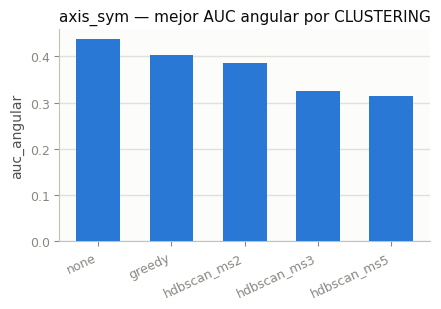

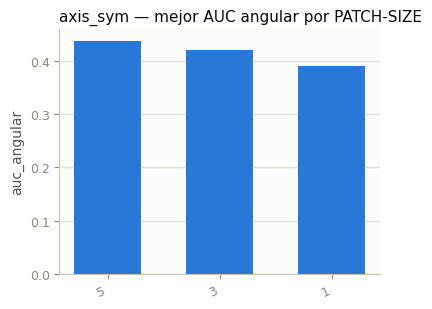

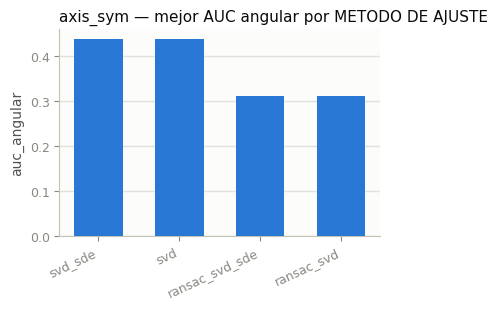

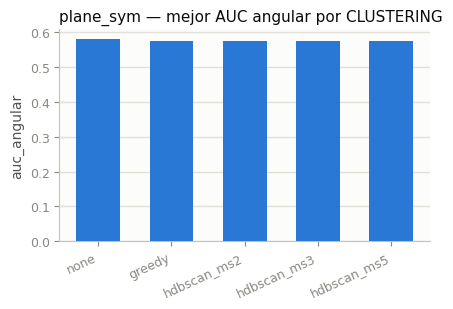

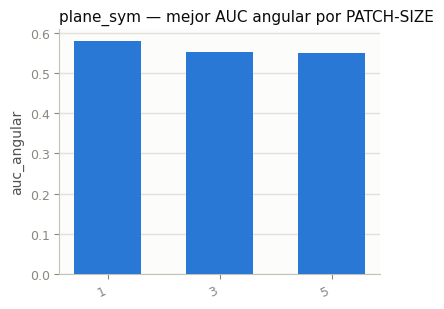

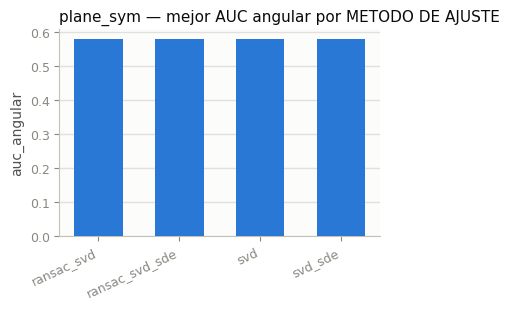

In [18]:
import matplotlib.pyplot as plt

# Paleta validada (references/palette.md del skill de dataviz) — modo claro, slots categoricos
# en orden fijo (nunca ciclados) mas los tokens de "chrome" (grid/ejes/texto).
PALETTE = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
CHROME = {
    "primary_ink": "#0b0b0b", "secondary_ink": "#52514e", "muted": "#898781",
    "gridline": "#e1e0d9", "baseline": "#c3c2b7", "surface": "#fcfcfb",
}


def _style_ax(ax, ylabel: str) -> None:
    ax.set_facecolor(CHROME["surface"])
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(CHROME["baseline"])
    ax.tick_params(colors=CHROME["muted"], labelsize=9)
    ax.yaxis.grid(True, color=CHROME["gridline"], linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylabel(ylabel, color=CHROME["secondary_ink"], fontsize=10)
    ax.set_xlabel("")


def plot_ablation_bar(df: pd.DataFrame, group_col: str, metric: str, ascending: bool, title: str) -> None:
    g = df.groupby(group_col)[metric]
    best = (g.min() if ascending else g.max()).sort_values(ascending=ascending)
    fig, ax = plt.subplots(figsize=(max(4, 0.9 * len(best)), 3.2))
    ax.bar(best.index.astype(str), best.values, color=PALETTE["blue"], width=0.6, zorder=3)
    _style_ax(ax, ylabel=metric)
    ax.set_title(title, color=CHROME["primary_ink"], fontsize=11, loc="left")
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
    fig.tight_layout()
    plt.show()


for label, df_, sym in [("axis_sym", axis_df, "axis"), ("plane_sym", plane_df, "plane")]:
    plot_ablation_bar(df_, "clustering", "auc_angular", False, f"{label} — mejor AUC angular por CLUSTERING")
    plot_ablation_bar(df_, "patch_size", "auc_angular", False, f"{label} — mejor AUC angular por PATCH-SIZE")
    plot_ablation_bar(df_, "method", "auc_angular", False, f"{label} — mejor AUC angular por METODO DE AJUSTE")

## 7c. Efecto de n_views — tendencia, v0 vs v1

¿Mas vistas mejora la precision? Promedio de `auc_angular` por `n_views`, separado por
`prompt_family` (dos series -> dos hues categoricos con leyenda, nunca color como unico
indicador). Un eje Y solamente (nunca doble eje).

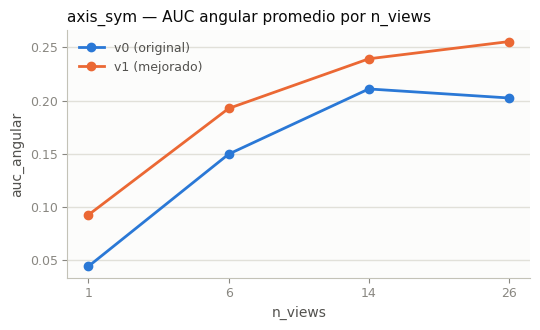

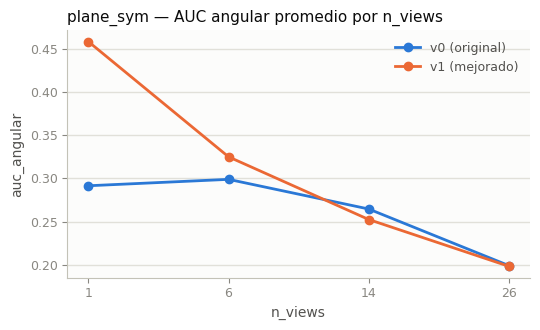

=== axis_sym - auc_angular promedio por n_views x prompt_family (tabla) ===


n_views,1,6,14,26
prompt_family,,,,
v0 (original),0.044452,0.149766,0.210955,0.202477
v1 (mejorado),0.092765,0.192655,0.239248,0.255420



=== plane_sym - auc_angular promedio por n_views x prompt_family (tabla) ===


n_views,1,6,14,26
prompt_family,,,,
v0 (original),0.291554,0.298962,0.264676,0.199268
v1 (mejorado),0.458162,0.324994,0.252550,0.198442


In [19]:
def plot_nviews_trend(df: pd.DataFrame, metric: str, title: str) -> None:
    fig, ax = plt.subplots(figsize=(5.5, 3.4))
    series_colors = [PALETTE["blue"], PALETTE["orange"]]
    for color, (family, sub) in zip(series_colors, sorted(df.groupby("prompt_family"))):
        trend = sub.groupby("n_views")[metric].mean().sort_index()
        ax.plot(trend.index.astype(str), trend.values, marker="o", markersize=6,
                linewidth=2, color=color, label=family, zorder=3)
    _style_ax(ax, ylabel=metric)
    ax.set_xlabel("n_views", color=CHROME["secondary_ink"], fontsize=10)
    ax.set_title(title, color=CHROME["primary_ink"], fontsize=11, loc="left")
    ax.legend(frameon=False, labelcolor=CHROME["secondary_ink"], fontsize=9, loc="best")
    fig.tight_layout()
    plt.show()


plot_nviews_trend(axis_df, "auc_angular", "axis_sym — AUC angular promedio por n_views")
plot_nviews_trend(plane_df, "auc_angular", "plane_sym — AUC angular promedio por n_views")

print("=== axis_sym - auc_angular promedio por n_views x prompt_family (tabla) ===")
display(axis_df.groupby(["prompt_family", "n_views"])["auc_angular"].mean().unstack("n_views"))
print("\n=== plane_sym - auc_angular promedio por n_views x prompt_family (tabla) ===")
display(plane_df.groupby(["prompt_family", "n_views"])["auc_angular"].mean().unstack("n_views"))

## 8. Ranking conjunto — axis_sym / plane_sym

Combina dos metricas por suma de rangos (rango 1 = mejor en cada metrica, menor suma = mejor
combinado). Es un empate ponderado 50/50; ajusta la lista de metricas si quieres pesar una mas
que la otra.

In [20]:
print(f"=== axis_sym - ranking CONJUNTO (auc_angular desc + angular_error_mean asc) - top {TOP_N} ===")
axis_combined = combined_rank(axis_df, [("auc_angular", False), ("angular_error_mean", True)])
display(axis_combined.head(TOP_N))

=== axis_sym - ranking CONJUNTO (auc_angular desc + angular_error_mean asc) - top 15 ===


,experiment,base_prompt,prompt_family,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,auc_angular,angular_error_mean,combined_rank
0,axis_v05_1_flowC_p5,axis_v05_1,v1 (mejorado),C,none,5,svd_sde,26,835,0.982353,0.4369,39.3026,2.0
1,axis_v05_1_flowC_p3,axis_v05_1,v1 (mejorado),C,none,3,svd_sde,26,829,0.975294,0.4197,40.5276,6.0
2,axis_v02_1_p5,axis_v02_1,v1 (mejorado),A,none,5,svd_sde,26,759,0.892941,0.4068,43.0767,14.0
3,axis_v05_1_flowB_p5,axis_v05_1,v1 (mejorado),B,none,5,svd_sde,26,769,0.904706,0.4039,43.6172,22.0
4,axis_v05_1_p5,axis_v05_1,v1 (mejorado),A,none,5,svd_sde,26,771,0.907059,0.3994,43.4657,22.0
5,axis_v05_p5,axis_v05,v0 (original),A,none,5,svd_sde,14,808,0.950588,0.3899,42.4140,24.0
6,axis_v05_1_flowC,axis_v05_1,v1 (mejorado),C,none,1,svd_sde,26,816,0.960000,0.3904,43.0070,24.0
7,axis_v05_1_p5_cluster,axis_v05_1,v1 (mejorado),A,greedy,5,svd_sde,26,769,0.904706,0.4024,43.7057,26.0
8,axis_v05_1_flowC_cluster,axis_v05_1,v1 (mejorado),C,greedy,1,svd_sde,26,814,0.957647,0.3875,43.5616,36.0
9,axis_v05_1_p3,axis_v05_1,v1 (mejorado),A,none,3,svd_sde,26,752,0.884706,0.3914,44.4495,46.0


In [21]:
print(f"=== plane_sym - ranking CONJUNTO (auc_angular desc + sde_mean asc) - top {TOP_N} ===")
plane_combined = combined_rank(plane_df, [("auc_angular", False), ("sde_mean", True)])
display(plane_combined.head(TOP_N))

=== plane_sym - ranking CONJUNTO (auc_angular desc + sde_mean asc) - top 15 ===


,experiment,base_prompt,prompt_family,flow,clustering,patch_size,method,n_views,n_objects,acceptance_rate,auc_angular,sde_mean,combined_rank
0,plane_v04_p5,plane_v04,v0 (original),A,none,5,svd_sde,6,846,0.995294,0.3464,0.224231,638.0
1,plane_v04_p3,plane_v04,v0 (original),A,none,3,svd_sde,6,842,0.990588,0.3755,0.241093,668.0
2,plane_v02_p3,plane_v02,v0 (original),A,none,3,svd_sde,6,832,0.978824,0.3431,0.230088,692.0
3,plane_v02_p5,plane_v02,v0 (original),A,none,5,svd_sde,6,839,0.987059,0.3200,0.218707,706.0
4,plane_v02,plane_v02,v0 (original),A,none,1,svd_sde,6,821,0.965882,0.3621,0.245293,716.0
5,plane_v04_1_p5_hdbscan_ms5,plane_v04_1,v1 (mejorado),A,hdbscan_ms5,5,svd_sde,6,846,0.995294,0.3787,0.253169,742.0
6,plane_v02_cluster,plane_v02,v0 (original),A,greedy,1,svd_sde,6,821,0.965882,0.3597,0.246056,748.0
7,plane_v04,plane_v04,v0 (original),A,none,1,svd_sde,6,815,0.958824,0.4101,0.261715,750.0
8,plane_v04_1,plane_v04_1,v1 (mejorado),A,none,1,svd_sde,6,830,0.976471,0.3521,0.245370,766.0
9,plane_v04_cluster,plane_v04,v0 (original),A,greedy,1,svd_sde,6,815,0.958824,0.4064,0.262568,768.0


## 9. Guardar los rankings

Exporta las tablas completas (no solo el top N) a `results/experiments_.../rankings/`: un
ranking por experimento y un ranking por prompt por cada metrica, mas los dos rankings
conjuntos.

In [22]:
OUT_DIR = EXPERIMENTS_DIR / "rankings"
OUT_DIR.mkdir(parents=True, exist_ok=True)

for label, (metric, ascending) in AXIS_METRICS.items():
    best_per_experiment(axis_df, metric, ascending).to_csv(OUT_DIR / f"axis_sym_ranking_{metric}.csv", index=False)
    best_per_prompt(axis_df, metric, ascending).to_csv(OUT_DIR / f"axis_sym_ranking_by_prompt_{metric}.csv", index=False)

for label, (metric, ascending) in PLANE_METRICS.items():
    best_per_experiment(plane_df, metric, ascending).to_csv(OUT_DIR / f"plane_sym_ranking_{metric}.csv", index=False)
    best_per_prompt(plane_df, metric, ascending).to_csv(OUT_DIR / f"plane_sym_ranking_by_prompt_{metric}.csv", index=False)

axis_combined.to_csv(OUT_DIR / "axis_sym_ranking_combined.csv", index=False)
plane_combined.to_csv(OUT_DIR / "plane_sym_ranking_combined.csv", index=False)

# Ablation (clustering, patch_size, method, point_mode, flow) por eje limpio
for group_col in ["clustering", "patch_size", "method", "point_mode", "flow"]:
    ablation_table(axis_df, group_col, AXIS_METRICS).to_csv(OUT_DIR / f"axis_sym_ablation_{group_col}.csv")
    ablation_table(plane_df, group_col, PLANE_METRICS).to_csv(OUT_DIR / f"plane_sym_ablation_{group_col}.csv")

# Reporte de validacion de integridad (hallazgos de la seccion 1b), para dejar constancia
# de que corte de datos se valido y con que resultado.
with open(OUT_DIR / "validation_report.txt", "w", encoding="utf-8") as f:
    f.write(f"Validado: {EXPERIMENTS_DIR}\n\n")
    for label, v in [("axis_sym", _axis_validation), ("plane_sym", _plane_validation)]:
        f.write(f"{label} — ganador (Flow B/C): {v['winner']}\n")
        f.write(f"{label} — prompts sin post-procesar: {sorted(v['missing_prompts']) or 'ninguno'}\n")
        f.write(f"{label} — hallazgos: {v['issues'] or 'ninguno (datos limpios)'}\n\n")
    f.write(f"Experiment ids en ambos symmetry_type (contaminacion cruzada): {sorted(_cross) or 'ninguno'}\n")

print(f"Guardado en: {OUT_DIR}")

Guardado en: experiments_17_08_2026\rankings


## Anexo — Reporte de errores en logs de ejecucion

Fuera del alcance del ranking de metricas: revisa `log_postprocesos.txt` /
`log_postprocesos_full.txt` en la raiz del repo en busca de lineas con palabras clave de
error/fallo, como reporte rapido de que tan limpia corrio la ultima tanda de post-procesamiento.

In [23]:
from pathlib import Path

LOG_FILES = [
    "log_postprocesos.txt",
    "log_postprocesos_full.txt",
]

# Palabras clave tipicas de error/fallo (ajusta segun lo que uses en tus scripts)
ERROR_KEYWORDS = [
    "error", "Error", "ERROR",
    "traceback", "Traceback",
    "exception", "Exception",
    "failed", "Failed", "FAILED",
    "fatal", "Fatal", "FATAL",
    "critical", "CRITICAL",
    "not found", "NotFound",
    "raise ",
]

for log_path in LOG_FILES:
    path = Path(log_path)
    if not path.exists():
        print(f"[!] No encontrado: {log_path}")
        continue

    print(f"\n{'='*80}\n{log_path}\n{'='*80}")
    matches = 0
    with path.open("r", encoding="utf-8", errors="replace") as f:
        for lineno, line in enumerate(f, start=1):
            if any(kw in line for kw in ERROR_KEYWORDS):
                print(f"L{lineno}: {line.rstrip()}")
                matches += 1

    print(f"\n--> Total de lineas con posibles errores en {log_path}: {matches}")


log_postprocesos.txt
L385: [2026-07-21 17:29:48]                              |   stderr> Traceback (most recent call last):
L400: [2026-07-21 17:29:48]                              |   stderr> json.decoder.JSONDecodeError: Expecting ',' delimiter: line 344 column 33 (char 8170)
L521: [2026-07-21 19:33:31]                              |   stderr> Traceback (most recent call last):
L535: [2026-07-21 19:33:31]                              |   stderr>     raise JSONDecodeError("Expecting value", s, err.value) from None
L536: [2026-07-21 19:33:31]                              |   stderr> json.decoder.JSONDecodeError: Expecting value: line 1 column 1 (char 0)

--> Total de lineas con posibles errores en log_postprocesos.txt: 5

log_postprocesos_full.txt
L5:       experiment         method  n_views  n_objects  angular_error_mean  angular_error_median  auc_angular  precision_5deg  precision_10deg
L23: Saved: ../results/axis_sym/per_experiment/axis_v00_cluster/plots/axis_sym_axis_v00_cluster_